# Decay Comparison Across Tools

Compare every available average and center concentration from BioDynaMo, Chaste, CompuTiX, PhysiCell, and TiSim with the analytical CSV reference at matching timestamps (within 0.0005 minutes; tool timestamps preserved as loaded).

1. Load all runs except the CompuTiX 0.0006-second runs; include its four 0.006-second runs.
2. Preserve the CSV timestamps and match each tool sample to the nearest analytical CSV row within 0.0005 minutes, without recalculation or interpolation.
3. Export pointwise absolute/relative errors and per-run mean errors for both concentrations.
4. Select one run per tool by lowest average-concentration mean absolute error (MAE), and reuse it for all plots.
5. Plot absolute error, then relative error, and a Nature-style concentration/error figure.


In [19]:
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


## Step 1: Define Study Paths And Shared Physical Parameters

The five tools store their outputs in different formats, but they all represent the same decay setup.
All tools, including TiSim, now provide both the whole-box average and center concentration for comparison.

In [20]:
ROOT = Path('/home/tntiniak/Work/observatory_benchmark')

BIODYNAMO_DIR = ROOT / 'Biodynamo' / 'diffusion_decay_test'
CHASTE_DIR = ROOT / 'Chaste' / 'DiffusionNoCells'
COMPUTIX_DIR = ROOT / 'CompuTiX' / 'diffusion_single' / 'Decay'
PHYSICELL_DIR = ROOT / 'PhysiCell' / 'results' / 'diffusion_decay'
ANALYTICAL_DIR = ROOT / 'ResultAnalysis' /'analytical_solutions' / 'diffusion' / 'Decay'
TISIM_DIR = ROOT / 'Tisim' / 'diffusion_decay_test'

## Step 2: Load The Analytical CSV


In [21]:
# The CSV is the only analytical reference, for both errors and plots.

analytical_df = pd.read_csv(
    ANALYTICAL_DIR / 'analytical_values.csv',
    usecols=['time_min', 'center_concentration_uM', 'average_concentration_uM'],
    dtype={
        'time_min': float,
        'center_concentration_uM': float,
        'average_concentration_uM': float,
    },
).rename(columns={
    'center_concentration_uM': 'analytical_center_uM',
    'average_concentration_uM': 'analytical_average_uM',
})
analytical_df


,time_min,analytical_center_uM,analytical_average_uM
0,0.000,10.000000,10.000000
1,0.001,9.990186,9.990315
2,0.002,9.980254,9.980813
3,0.003,9.970295,9.971454
4,0.004,9.960334,9.962214
...,...,...,...
9996,9.996,2.769876,6.858043
9997,9.997,2.769876,6.858043
9998,9.998,2.769876,6.858043
9999,9.999,2.769876,6.858043


## Step 3: Load Every Attached Result Into One Common Table

Each loader returns a table with the same columns: tool name, run identifier, time in minutes, spatial resolution in um, whole-box average concentration in uM, and center concentration in uM.

BioDynaMo uses columns 2 and 3 from the text file, Chaste uses `centre_concentration(uM)` and `average_concentration(uM)`, CompuTiX loads only `dt-s-0-006_N-*.yaml` (N = 7, 15, 31, 63) and uses `c_central` and `c_domain`, and PhysiCell reads the exported CSV generated from the microenvironment field.

TiSim loads `data_*.csv` from `Tisim/diffusion_decay_test`, using `time_min`, `average_uM`, and `center_uM` exactly as stored. This notebook does not read Excel, round timestamps, or interpolate concentrations. The existing CSV center values reflect the earlier export process and are used as provided.

Units are minutes and uM throughout: CompuTiX seconds are divided by 60 and mol/m³ multiplied by 1000. PhysiCell's exported concentrations already include the particles/µm³-to-uM conversion. Center values retain each tool's exported center definition (PhysiCell averages the central voxels); the reference is evaluated at the box center.


In [22]:
def format_resolution_label(tool: str, dx_um: float, n_voxels_per_dim: int | None = None, dt_min: float | None = None) -> str:

    if tool in {'BioDynaMo', 'Chaste'}:

        return f'N={n_voxels_per_dim} voxels/dim, dx={dx_um:.0f} um'

    if tool == 'CompuTiX':

        return f'N={n_voxels_per_dim} voxels/dim, dx={dx_um:.2f} um, dt={dt_min:.1e} min'

    if tool == 'PhysiCell':

        return f'voxel size={dx_um:.0f} um'

    if tool == 'TiSim':

        return f'N={n_voxels_per_dim} bins, dx={dx_um:.0f} um'

    return f'dx={dx_um:.0f} um'


def load_biodynamo_runs() -> list[pd.DataFrame]:

    runs = []

    for csv_path in sorted(BIODYNAMO_DIR.glob('data_*.csv')):

        n_voxels_per_dim = int(csv_path.stem.split('_')[1])

        dx_um = 240 / n_voxels_per_dim

        frame = pd.read_csv(csv_path, sep=r'\s+', header=None, names=['time_min', 'average_uM', 'center_uM'])

        run_id = f'BioDynaMo_N_{n_voxels_per_dim}'

        frame = frame.assign(
            tool='BioDynaMo',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='text file column 2: average_uM',
            center_source='text file column 3: center_uM',
            resolution_label=format_resolution_label('BioDynaMo', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim),
        )

        runs.append(
            frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']]
        )

    return runs


def load_chaste_runs() -> list[pd.DataFrame]:

    runs = []

    for dat_path in sorted(CHASTE_DIR.glob('*.dat')):

        n_voxels_per_dim = int(dat_path.stem)

        dx_um = 240 / n_voxels_per_dim

        frame = pd.read_csv(dat_path, sep=r'\s+')

        run_id = f'Chaste_N_{n_voxels_per_dim}'

        frame = frame.rename(columns={
            'time(minutes)': 'time_min',
            'centre_concentration(uM)': 'center_uM',
            'average_concentration(uM)': 'average_uM',
        })

        frame = frame.assign(
            tool='Chaste',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='table column: average_concentration(uM)',
            center_source='table column: centre_concentration(uM)',
            resolution_label=format_resolution_label('Chaste', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim),
        )

        runs.append(
            frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']]
        )

    return runs


def load_computix_runs() -> list[pd.DataFrame]:

    runs = []

    for yaml_path in sorted(COMPUTIX_DIR.glob('dt-s-0-006_N-*.yaml')):

        data = yaml.load(yaml_path.read_text(), Loader=getattr(yaml, 'CSafeLoader', yaml.SafeLoader))

        dx_um = float(data['dx']['values']) * 1e6

        dt_min = float(data['dt']['values']) / 60.0

        n_voxels_per_dim = int(data['N']['values'])

        frame = pd.DataFrame({
            'time_min': np.array(data['time_series']['values']['t']['values'], dtype=float) / 60.0,
            'average_uM': 1e3 * np.array(data['time_series']['values']['c_domain']['values'], dtype=float),
            'center_uM': 1e3 * np.array(data['time_series']['values']['c_central']['values'], dtype=float),
        })

        run_id = f'CompuTiX_N_{n_voxels_per_dim}_dt_{dt_min:.5g}min'

        frame = frame.assign(
            tool='CompuTiX',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=dt_min,
            average_source='YAML time_series.values.c_domain.values',
            center_source='YAML time_series.values.c_central.values',
            resolution_label=format_resolution_label('CompuTiX', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim, dt_min=dt_min),
        )

        runs.append(
            frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']]
        )

    return runs


def load_physicell_runs() -> list[pd.DataFrame]:

    csv_paths = [
        path
        for path in sorted(PHYSICELL_DIR.glob('size_*/physicell_decay_plot_data.csv'))
        if not path.parent.name.endswith('_uptake')
    ]
    if not csv_paths:
        raise FileNotFoundError(
            f'No PhysiCell export CSVs found in {PHYSICELL_DIR}. Run export_physicell_decay_csv.ipynb first.'
        )

    required_columns = [
        'tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source',
        'resolution_label', 'time_min', 'average_uM', 'center_uM',
    ]

    runs = []

    for csv_path in csv_paths:
        frame = pd.read_csv(csv_path)
        missing_columns = [column for column in required_columns if column not in frame.columns]
        if missing_columns:
            raise ValueError(f'{csv_path} is missing required columns: {missing_columns}')

        runs.append(frame[required_columns].copy())

    return runs


def load_tisim_runs() -> list[pd.DataFrame]:
    runs = []
    for csv_path in sorted(TISIM_DIR.glob('data_*.csv')):
        n_bins = int(csv_path.stem.split('_')[1])
        dx_um = 240 / n_bins
        # Keep timestamps and concentrations exactly as read: no rounding or interpolation.
        frame = pd.read_csv(csv_path)
        frame = frame.assign(
            tool='TiSim',
            run_id=f'TiSim_N_{n_bins}',
            dx_um=dx_um,
            dt_min=np.nan,
            average_source=f'{csv_path.name}: average_uM',
            center_source=f'{csv_path.name}: center_uM',
            resolution_label=format_resolution_label('TiSim', dx_um=dx_um, n_voxels_per_dim=n_bins),
        )
        runs.append(
            frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source',
                   'resolution_label', 'time_min', 'average_uM', 'center_uM']]
        )
    return runs


all_runs = pd.concat(
    load_biodynamo_runs() + load_chaste_runs() + load_computix_runs() + load_physicell_runs() + load_tisim_runs(),
    ignore_index=True,
)

assert set(all_runs['tool']) == {'BioDynaMo', 'Chaste', 'CompuTiX', 'PhysiCell', 'TiSim'}
assert (all_runs['average_uM'].notna() | all_runs['center_uM'].notna()).all()
assert np.isfinite(all_runs['time_min']).all() and all_runs['time_min'].ge(0).all()
assert not all_runs.duplicated(['tool', 'run_id', 'time_min']).any()
for column in ['average_uM', 'center_uM']:
    assert np.isfinite(all_runs[column].dropna()).all()

run_catalog = (
    all_runs[
        ['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label']
    ]
    .drop_duplicates()
    .sort_values(['tool', 'dx_um', 'dt_min'])
)

plot_output_dir = ROOT / 'SuppMat' / 'SuppMatPlots'/ 'diffusion_decay_comparison'
plot_output_dir.mkdir(parents=True, exist_ok=True)

run_catalog

,tool,run_id,dx_um,dt_min,average_source,center_source,resolution_label
11000,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=48 voxels/dim, dx=5 um"
1000,BioDynaMo,BioDynaMo_N_24,10.00000,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=24 voxels/dim, dx=10 um"
0,BioDynaMo,BioDynaMo_N_12,20.00000,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=12 voxels/dim, dx=20 um"
21000,BioDynaMo,BioDynaMo_N_6,40.00000,NaN,text file column 2: average_uM,text file column 3: center_uM,"N=6 voxels/dim, dx=40 um"
24002,Chaste,Chaste_N_48,5.00000,NaN,table column: average_concentration(uM),table column: centre_concentration(uM),"N=48 voxels/dim, dx=5 um"
23001,Chaste,Chaste_N_24,10.00000,NaN,table column: average_concentration(uM),table column: centre_concentration(uM),"N=24 voxels/dim, dx=10 um"
22000,Chaste,Chaste_N_12,20.00000,NaN,table column: average_concentration(uM),table column: centre_concentration(uM),"N=12 voxels/dim, dx=20 um"
25003,Chaste,Chaste_N_6,40.00000,NaN,table column: average_concentration(uM),table column: centre_concentration(uM),"N=6 voxels/dim, dx=40 um"
26204,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.0001,YAML time_series.values.c_domain.values,YAML time_series.values.c_central.values,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min"
26104,CompuTiX,CompuTiX_N_31_dt_0.0001min,7.74194,0.0001,YAML time_series.values.c_domain.values,YAML time_series.values.c_central.values,"N=31 voxels/dim, dx=7.74 um, dt=1.0e-04 min"


In [23]:
# Loaded sample counts are reused by the coverage check below.
loaded_sample_counts = all_runs.groupby(['tool', 'run_id'])[['average_uM', 'center_uM']].count()
loaded_sample_counts


average_uM  center_uM
tool      run_id                                           
BioDynaMo BioDynaMo_N_12                    1000       1000
          BioDynaMo_N_24                   10000      10000
          BioDynaMo_N_48                   10000      10000
          BioDynaMo_N_6                     1000       1000
Chaste    Chaste_N_12                       1001       1001
          Chaste_N_24                       1001       1001
          Chaste_N_48                       1001       1001
          Chaste_N_6                        1001       1001
CompuTiX  CompuTiX_N_15_dt_0.0001min         100        100
          CompuTiX_N_31_dt_0.0001min         100        100
          CompuTiX_N_63_dt_0.0001min         100        100
          CompuTiX_N_7_dt_0.0001min          100        100
PhysiCell PhysiCell_dx_10um                 1001       1001
          PhysiCell_dx_20um                 1001       1001
          PhysiCell_dx_40um                 1001       1001
          PhysiCell_dx_5um                  1001       1001
TiSim     TiSim_N_10                         201        201
          TiSim_N_20                         201        201
          TiSim_N_40                         201        201

## Step 4: Match Tool Times To The Analytical CSV

Load reference values only from `analytical_values.csv`. Without changing the loaded timestamps, match each tool timestamp to the nearest CSV timestamp within 0.0005 minutes (half the CSV grid spacing). Preserve both `time_min` and `analytical_time_min` so the match can be inspected. An unmatched sample raises an error rather than being dropped. No analytical code is run and no interpolation is used. Missing concentration observations are omitted only for that measure.

MAE is the arithmetic mean of all absolute errors; mean relative error is the arithmetic mean of `100 × |observed − analytical| / |analytical|`. A zero analytical concentration makes relative error undefined, but the absolute error is retained. Time-weighted means, L2 norms, maxima, counts, and time spans are also reported. Runs are scored over their full available time spans; their sampling frequency and end times differ slightly.


In [24]:
# Match existing CSV samples; never recompute or interpolate the reference.
TIME_MATCH_TOLERANCE_MIN = 0.0005  # Half the CSV's 0.001-minute spacing.
analytical_reference = analytical_df.rename(columns={'time_min': 'analytical_time_min'}).sort_values('analytical_time_min')
assert not analytical_reference['analytical_time_min'].duplicated().any()


def compare_run_at_native_times(run: pd.DataFrame) -> pd.DataFrame:
    matched = pd.merge_asof(
        run.sort_values('time_min'), analytical_reference,
        left_on='time_min', right_on='analytical_time_min',
        direction='nearest', tolerance=TIME_MATCH_TOLERANCE_MIN,
    )
    missing = matched['analytical_time_min'].isna()
    if missing.any():
        raise ValueError(
            f"{run['run_id'].iloc[0]}: no analytical CSV row within "
            f"{TIME_MATCH_TOLERANCE_MIN} min for {matched.loc[missing, 'time_min'].tolist()}"
        )
    assert len(matched) == len(run)
    assert np.isfinite(matched[['analytical_average_uM', 'analytical_center_uM']]).all().all()
    return matched.reset_index(drop=True)


def integrated_error_metrics(run: pd.DataFrame) -> pd.Series:
    run = run.sort_values('time_min')
    time_min = run['time_min'].to_numpy()
    duration_min = time_min[-1] - time_min[0]
    absolute_error_uM = run['absolute_error_uM'].to_numpy()
    relative_error_percent = run['relative_error_percent'].to_numpy()

    if duration_min <= 0:
        raise ValueError("Each run needs at least two distinct time points.")

    return pd.Series({
        'point_count': len(run),
        'duration_min': duration_min,
        'first_time_min': time_min[0],
        'last_time_min': time_min[-1],
        'relative_point_count': np.isfinite(relative_error_percent).sum(),
        'mean_absolute_error_uM': absolute_error_uM.mean(),
        'time_weighted_mean_absolute_error_uM': np.trapezoid(absolute_error_uM, time_min) / duration_min,
        'l2_error_uM': np.sqrt(np.trapezoid(absolute_error_uM**2, time_min) / duration_min),
        'max_absolute_error_uM': absolute_error_uM.max(),
        'mean_relative_error_percent': run['relative_error_percent'].mean(),
        'time_weighted_mean_relative_error_percent': np.trapezoid(relative_error_percent, time_min) / duration_min,
        'l2_relative_error_percent': np.sqrt(np.trapezoid(relative_error_percent**2, time_min) / duration_min),
        'max_relative_error_percent': relative_error_percent.max(),
    })


In [25]:
comparison_frames = []

for _, run in all_runs.groupby(['tool', 'run_id'], sort=False):
    matched = compare_run_at_native_times(run)

    for metric_name, observed_column, analytical_column in [
        ('average', 'average_uM', 'analytical_average_uM'),
        ('center', 'center_uM', 'analytical_center_uM'),
    ]:
        metric_frame = matched.dropna(subset=[observed_column]).copy()
        metric_frame['metric'] = metric_name
        metric_frame['absolute_error_uM'] = (
            metric_frame[observed_column] - metric_frame[analytical_column]
        ).abs()
        metric_frame['relative_error_percent'] = (
            metric_frame['absolute_error_uM']
            / metric_frame[analytical_column].abs().replace(0, np.nan)
            * 100
        )
        comparison_frames.append(metric_frame)

comparison = pd.concat(comparison_frames, ignore_index=True)
assert len(comparison) == all_runs[['average_uM', 'center_uM']].count().sum()

run_metrics = (
    comparison.groupby(
        ['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'],
        dropna=False,
    )
    .apply(integrated_error_metrics, include_groups=False)
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
)

comparison.to_csv(plot_output_dir / 'pointwise_errors.csv', index=False)
run_metrics.to_csv(plot_output_dir / 'run_error_metrics.csv', index=False)
run_metrics


,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,duration_min,first_time_min,last_time_min,relative_point_count,mean_absolute_error_uM,time_weighted_mean_absolute_error_uM,l2_error_uM,max_absolute_error_uM,mean_relative_error_percent,time_weighted_mean_relative_error_percent,l2_relative_error_percent,max_relative_error_percent
2,average,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",10000.0,9.9990,0.0,9.9990,10000.0,0.256956,0.256968,0.260234,0.271531,3.713181,3.713355,3.772463,3.959308
1,average,BioDynaMo,BioDynaMo_N_24,10.00000,NaN,"N=24 voxels/dim, dx=10 um",10000.0,9.9990,0.0,9.9990,10000.0,0.516512,0.516536,0.522809,0.544833,7.462604,7.462953,7.577639,7.944434
0,average,BioDynaMo,BioDynaMo_N_12,20.00000,NaN,"N=12 voxels/dim, dx=20 um",1000.0,9.9900,0.0,9.9900,1000.0,1.026833,1.027319,1.039334,1.081887,14.833485,14.840438,15.061902,15.775453
3,average,BioDynaMo,BioDynaMo_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",1000.0,9.9900,0.0,9.9900,1000.0,1.927276,1.928193,1.949079,2.023224,27.832950,27.846045,28.236394,29.501456
6,average,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",1001.0,10.0000,0.0,10.0000,1001.0,0.186791,0.186880,0.188729,0.195607,2.696681,2.697951,2.733198,2.852234
5,average,Chaste,Chaste_N_24,10.00000,NaN,"N=24 voxels/dim, dx=10 um",1001.0,10.0000,0.0,10.0000,1001.0,0.369517,0.369693,0.373411,0.386807,5.334994,5.337509,5.408013,5.640198
4,average,Chaste,Chaste_N_12,20.00000,NaN,"N=12 voxels/dim, dx=20 um",1001.0,10.0000,0.0,10.0000,1001.0,0.720656,0.720999,0.728315,0.754572,10.404994,10.409897,10.548392,11.002726
7,average,Chaste,Chaste_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",1001.0,10.0000,0.0,10.0000,1001.0,1.343214,1.343854,1.357657,1.407251,19.394530,19.403664,19.664389,20.519722
10,average,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.0001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min",100.0,9.9001,0.0,9.9001,100.0,0.196892,0.197821,0.200564,0.209715,2.845969,2.859274,2.907932,3.057939
9,average,CompuTiX,CompuTiX_N_31_dt_0.0001min,7.74194,0.0001,"N=31 voxels/dim, dx=7.74 um, dt=1.0e-04 min",100.0,9.9001,0.0,9.9001,100.0,0.387213,0.389039,0.394621,0.413024,5.597773,5.623904,5.722241,6.022479


## Check Sample Coverage

Confirm that every loaded concentration sample was compared.


In [26]:
# Reuse the per-run metrics instead of aggregating the same coverage again.
native_timepoint_coverage = run_metrics[[
    'metric', 'tool', 'run_id', 'point_count', 'first_time_min', 'last_time_min',
]].rename(columns={'point_count': 'compared_points'}).copy()
native_timepoint_coverage['compared_points'] = native_timepoint_coverage['compared_points'].astype(int)
for metric in ['average', 'center']:
    actual = comparison.loc[comparison['metric'] == metric].groupby(['tool', 'run_id']).size()
    pd.testing.assert_series_equal(actual, loaded_sample_counts[f'{metric}_uM'], check_names=False)
native_timepoint_coverage


,metric,tool,run_id,compared_points,first_time_min,last_time_min
2,average,BioDynaMo,BioDynaMo_N_48,10000,0.0,9.9990
1,average,BioDynaMo,BioDynaMo_N_24,10000,0.0,9.9990
0,average,BioDynaMo,BioDynaMo_N_12,1000,0.0,9.9900
3,average,BioDynaMo,BioDynaMo_N_6,1000,0.0,9.9900
6,average,Chaste,Chaste_N_48,1001,0.0,10.0000
5,average,Chaste,Chaste_N_24,1001,0.0,10.0000
4,average,Chaste,Chaste_N_12,1001,0.0,10.0000
7,average,Chaste,Chaste_N_6,1001,0.0,10.0000
10,average,CompuTiX,CompuTiX_N_63_dt_0.0001min,100,0.0,9.9001
9,average,CompuTiX,CompuTiX_N_31_dt_0.0001min,100,0.0,9.9001


## Mean Relative Error For Every Run

Both concentration measures are summarized below; these plots do not change the average-based run selection.


In [27]:
tool_colors = {
    'BioDynaMo': '#ff7f00',
    'Chaste': '#377eb8',
    'CompuTiX': '#fd2a2a',
    'PhysiCell': '#4daf4a',
    'TiSim': '#984ea3',
}

metric_titles = {
    'average': 'Whole-box average concentration',
    'center': 'Center concentration',
}

metric_file_tokens = {
    'average': 'whole_box_average',
    'center': 'center_concentration',
}

plt.rcParams.update({
    'figure.dpi': 160,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})


def style_axis(axis) -> None:
    axis.set_facecolor('#fbfbfc')
    axis.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.35)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_color('#4a4a4a')
    axis.spines['bottom'].set_color('#4a4a4a')


def save_and_show(fig, filename: str) -> None:
    fig.savefig(plot_output_dir / filename, bbox_inches='tight', dpi=300, facecolor='white')
    plt.show()
    plt.close(fig)


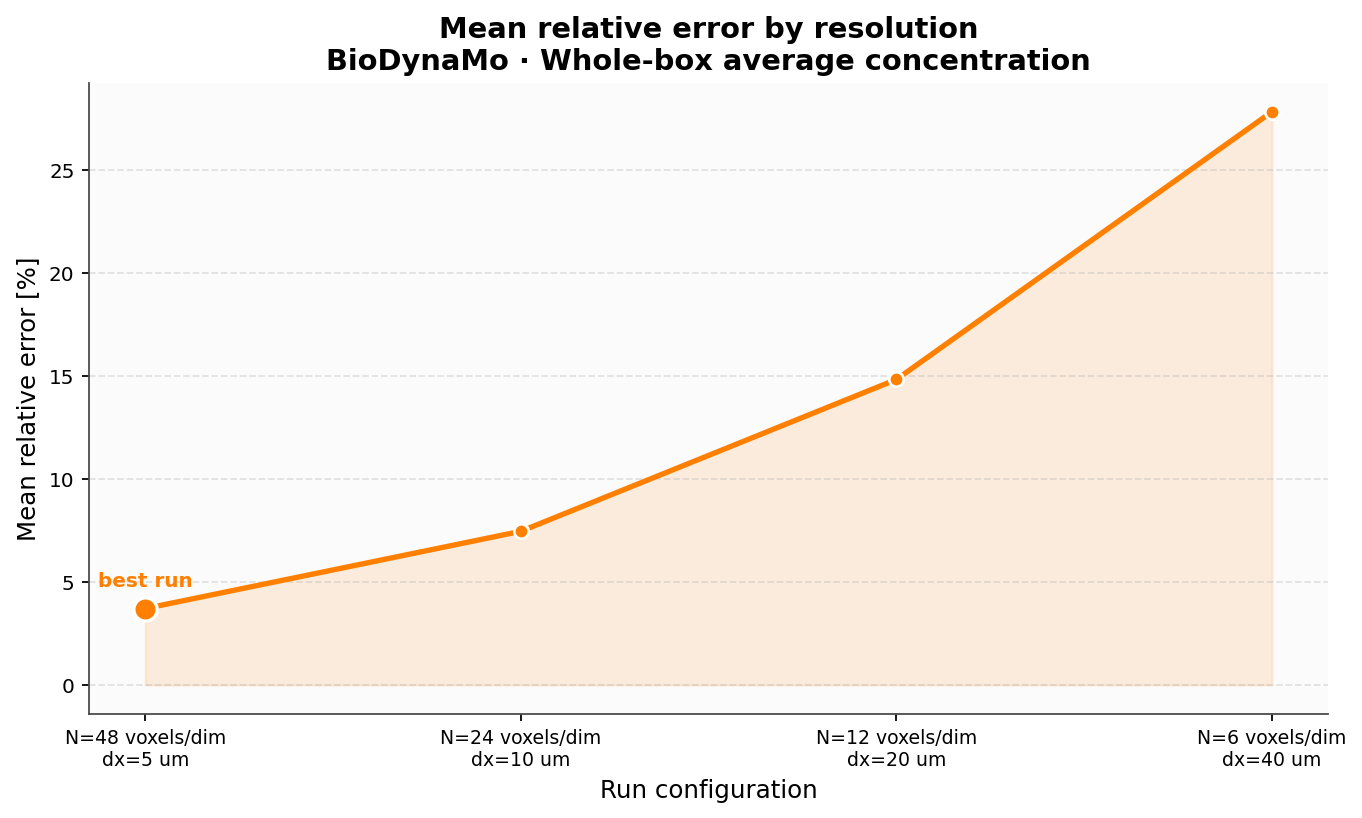

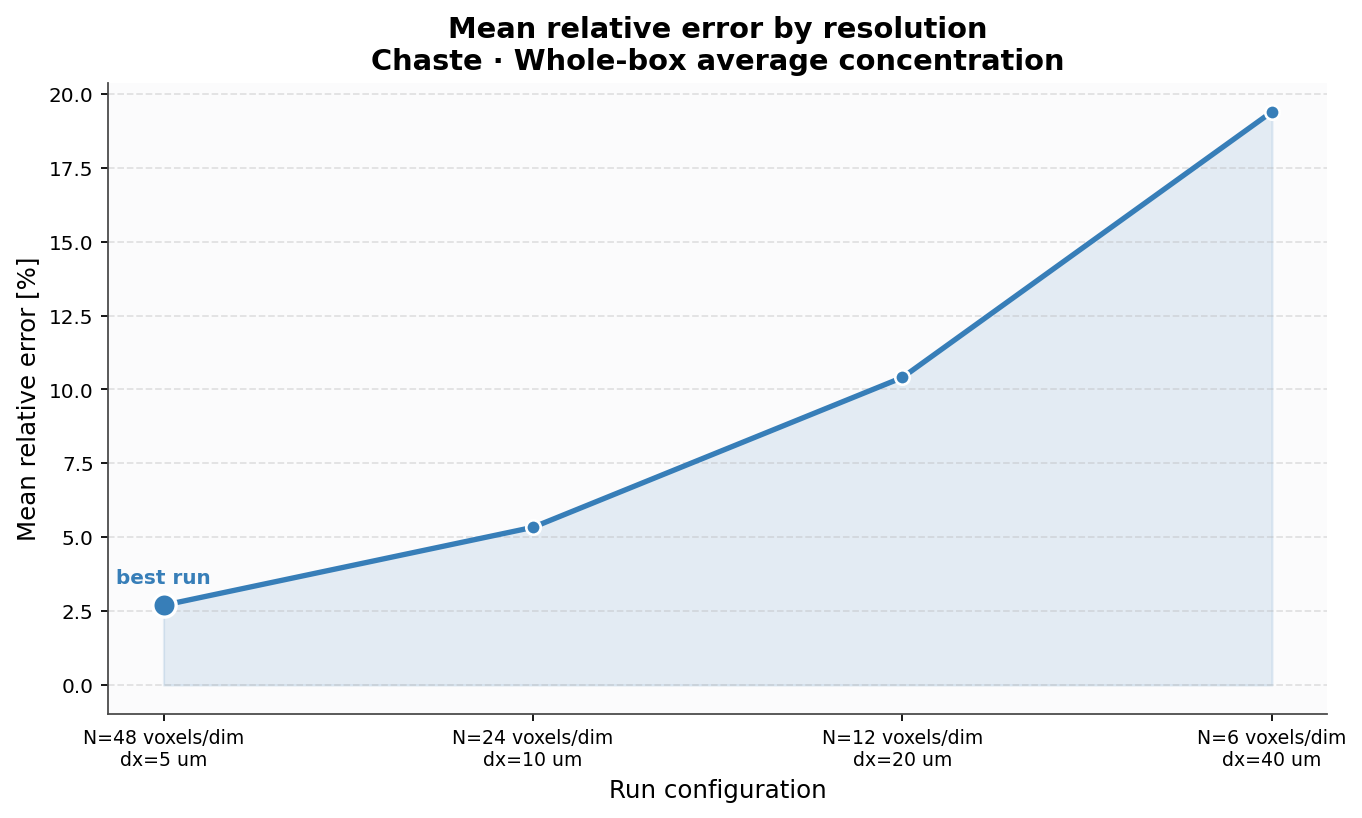

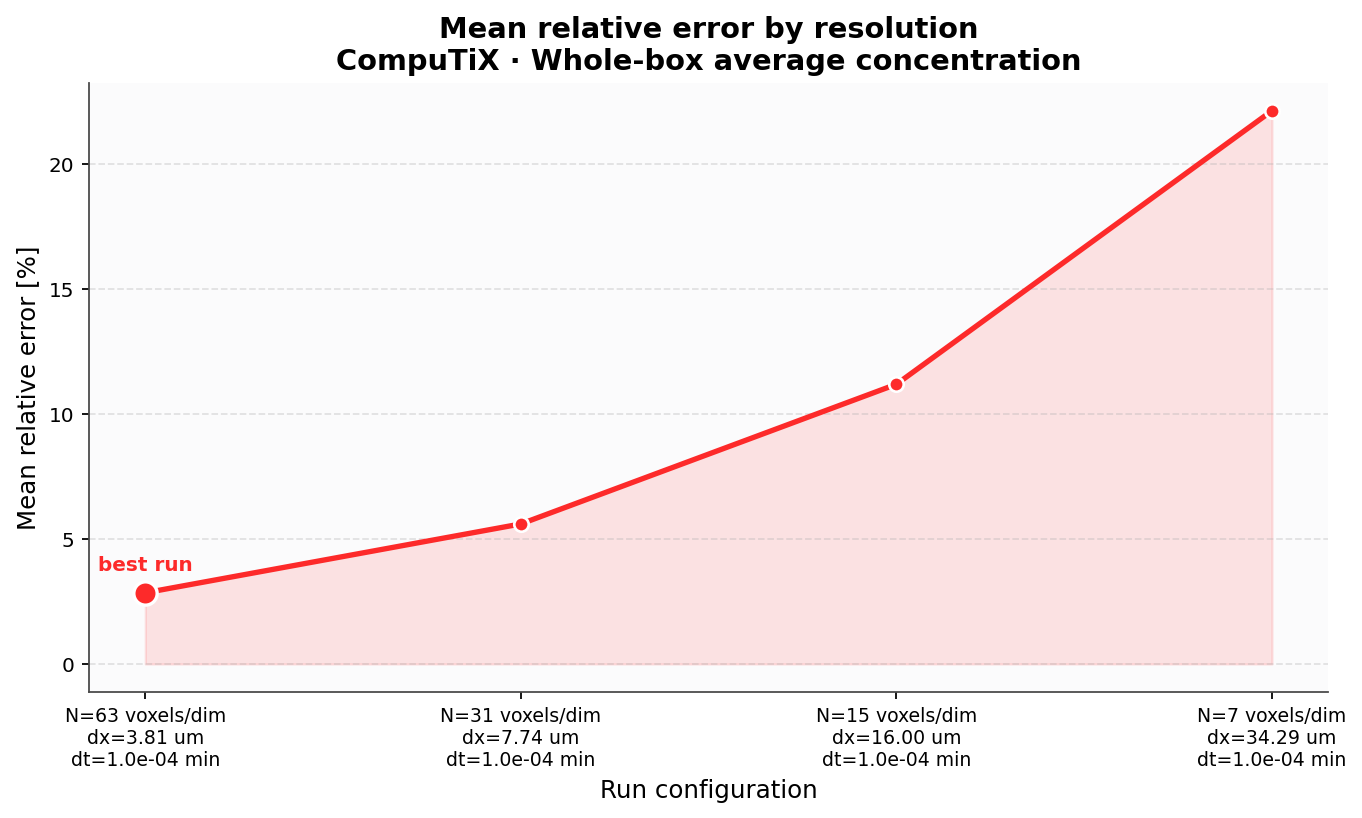

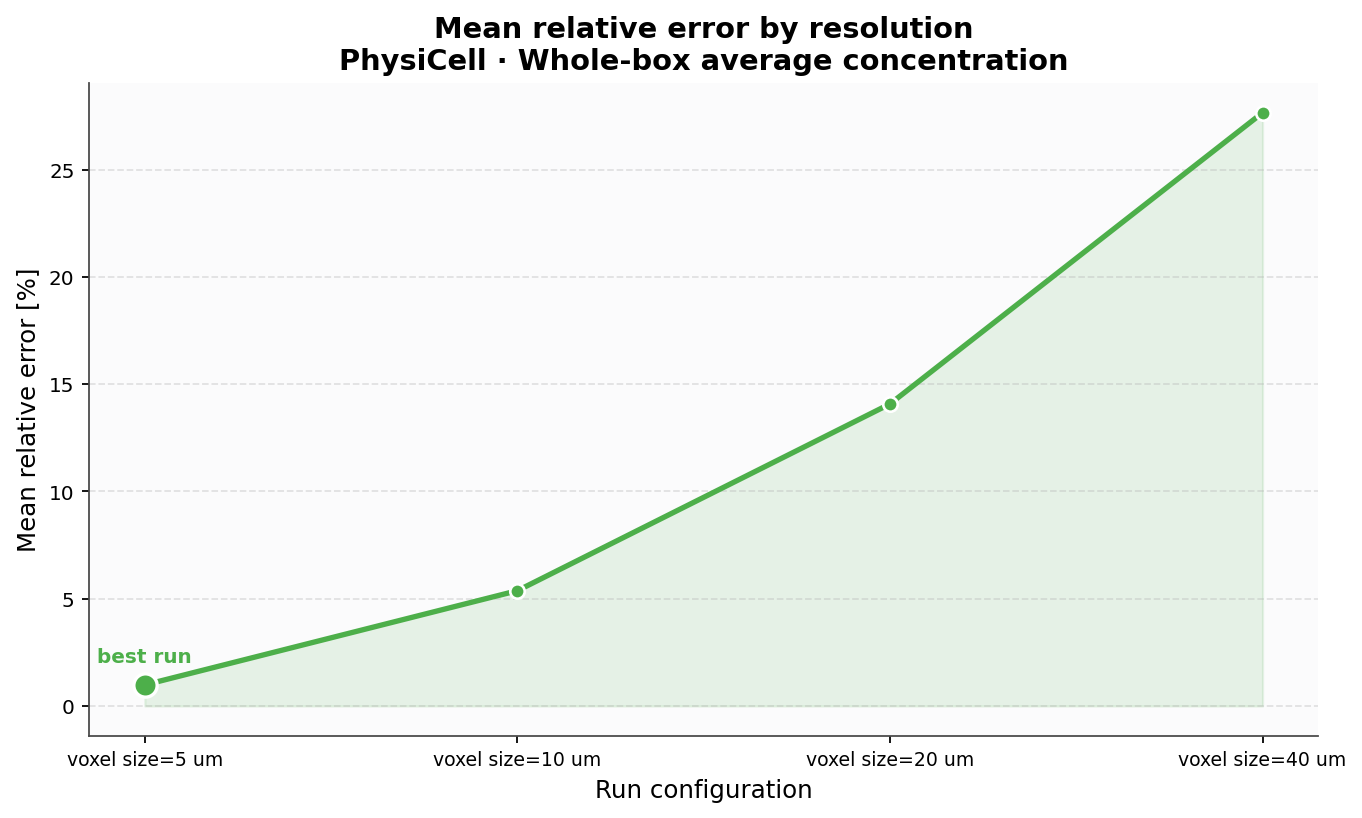

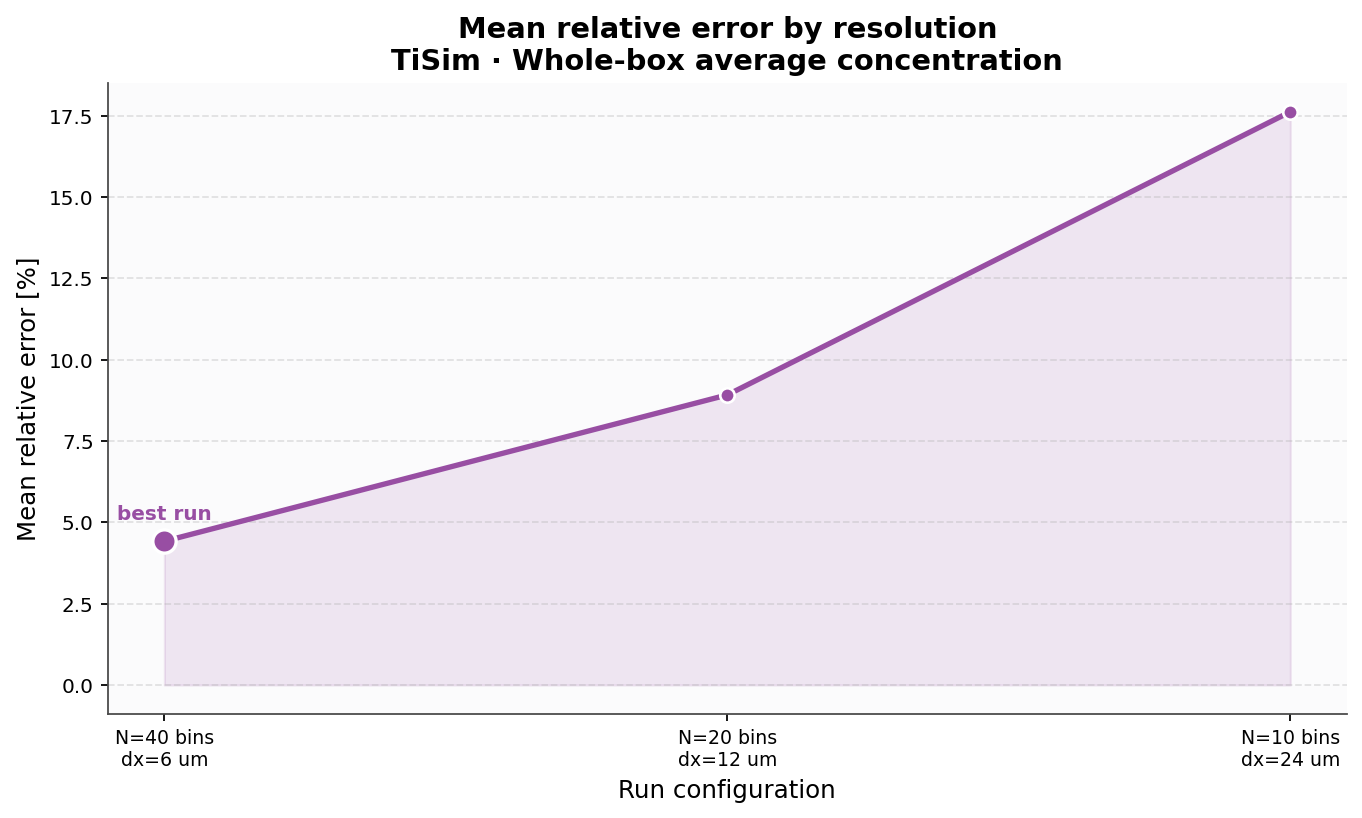

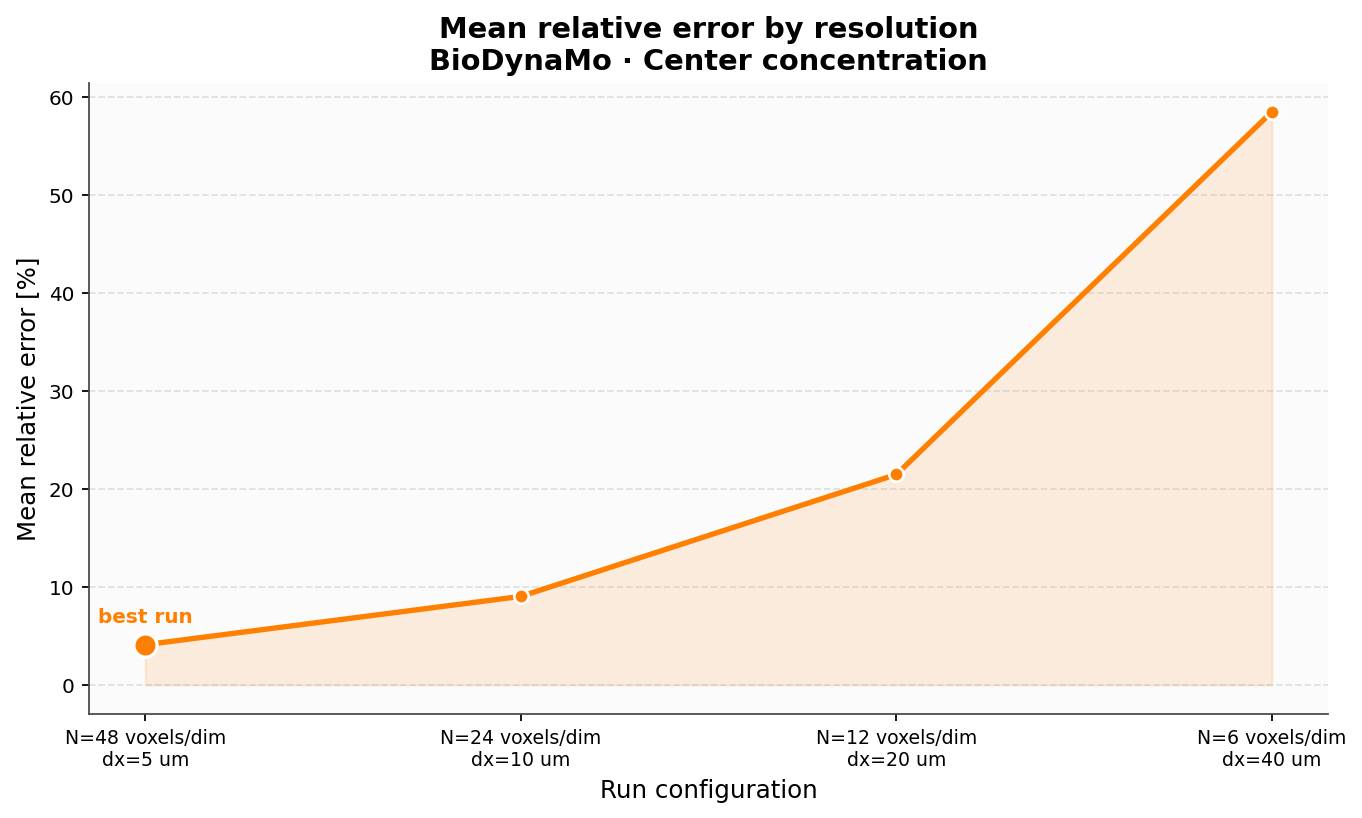

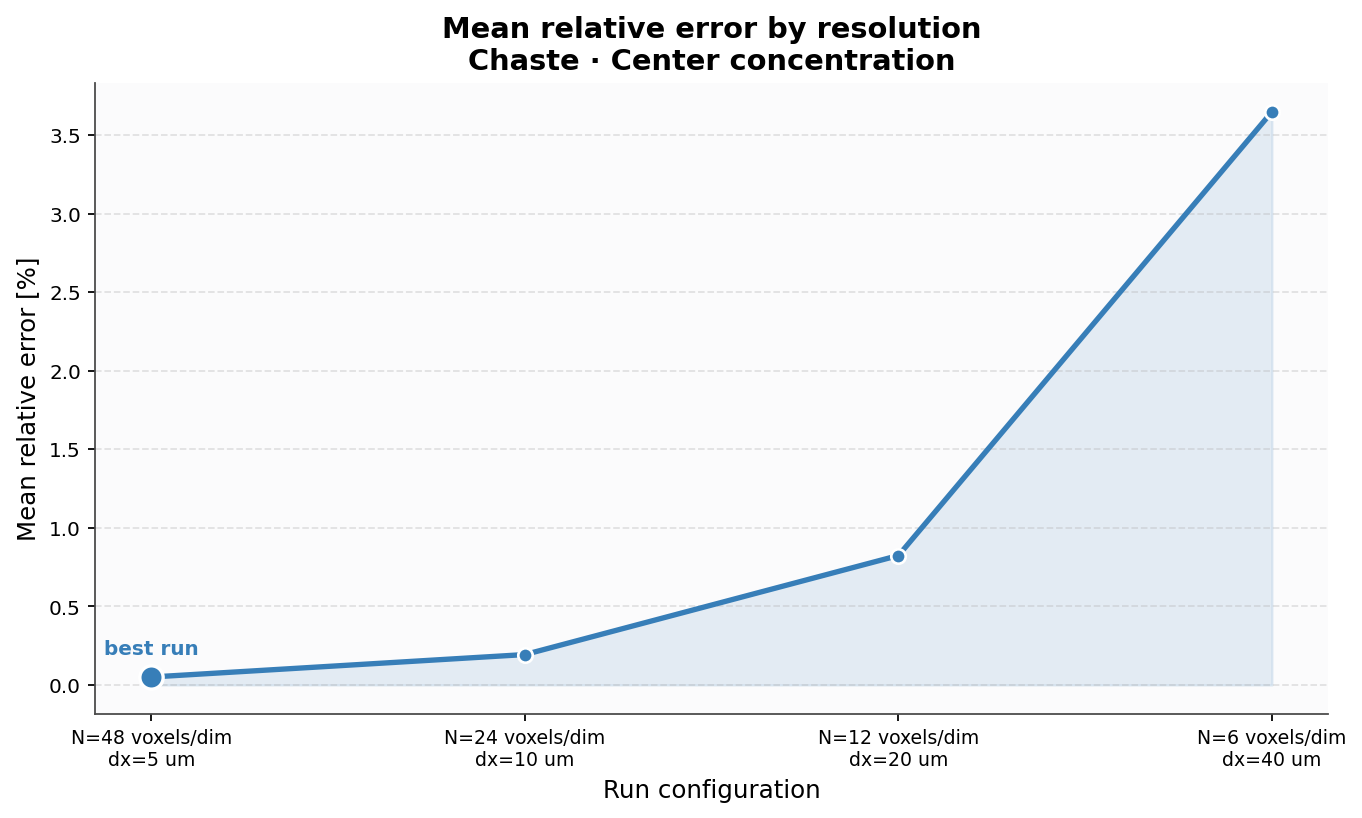

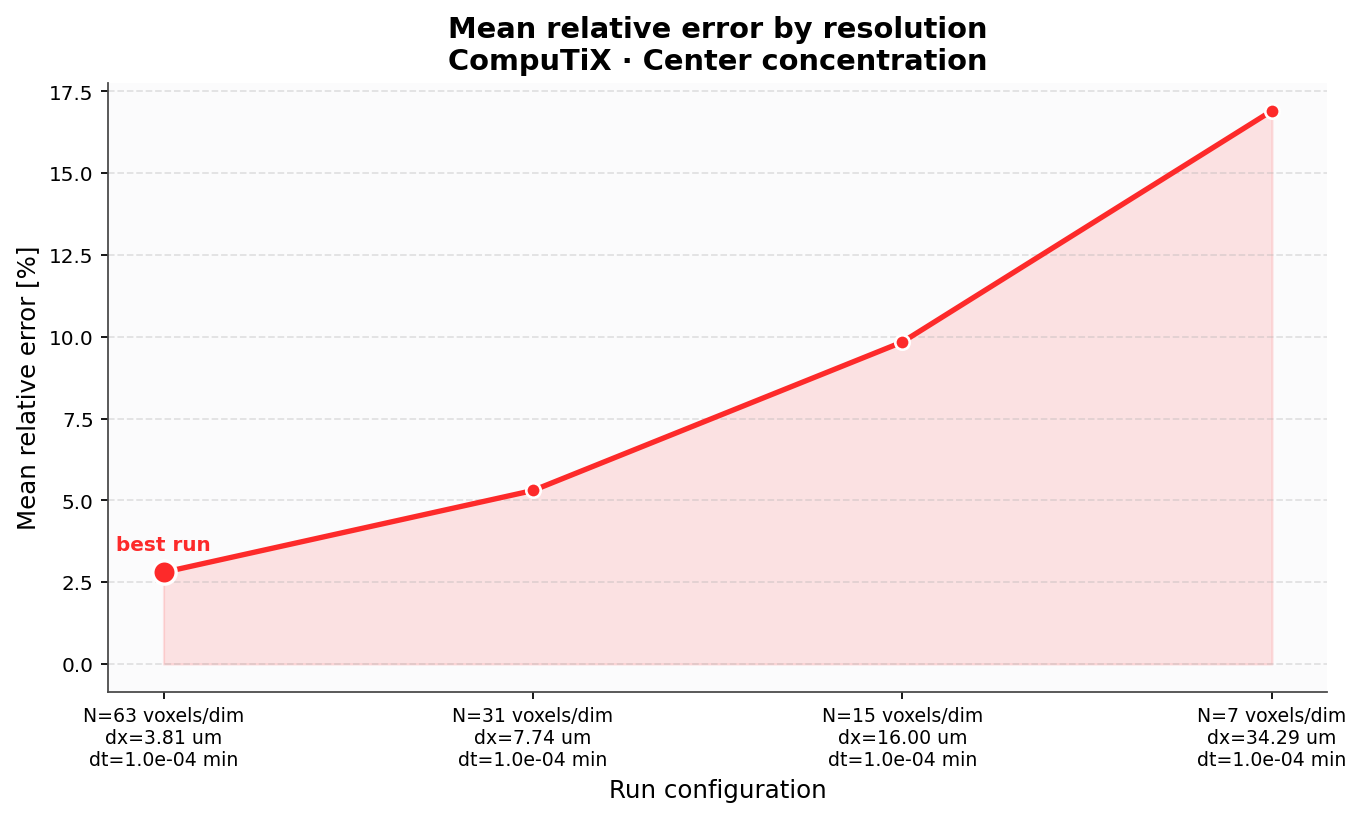

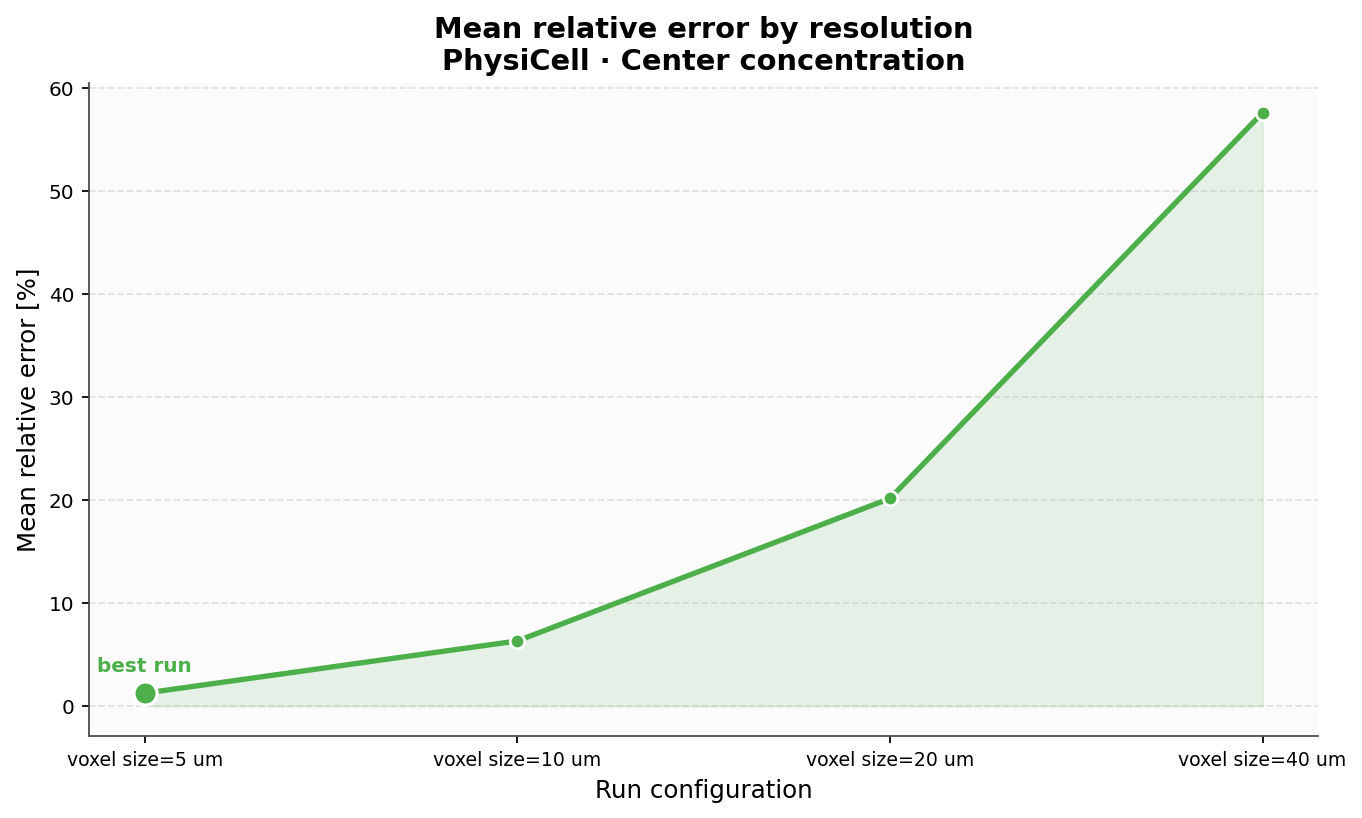

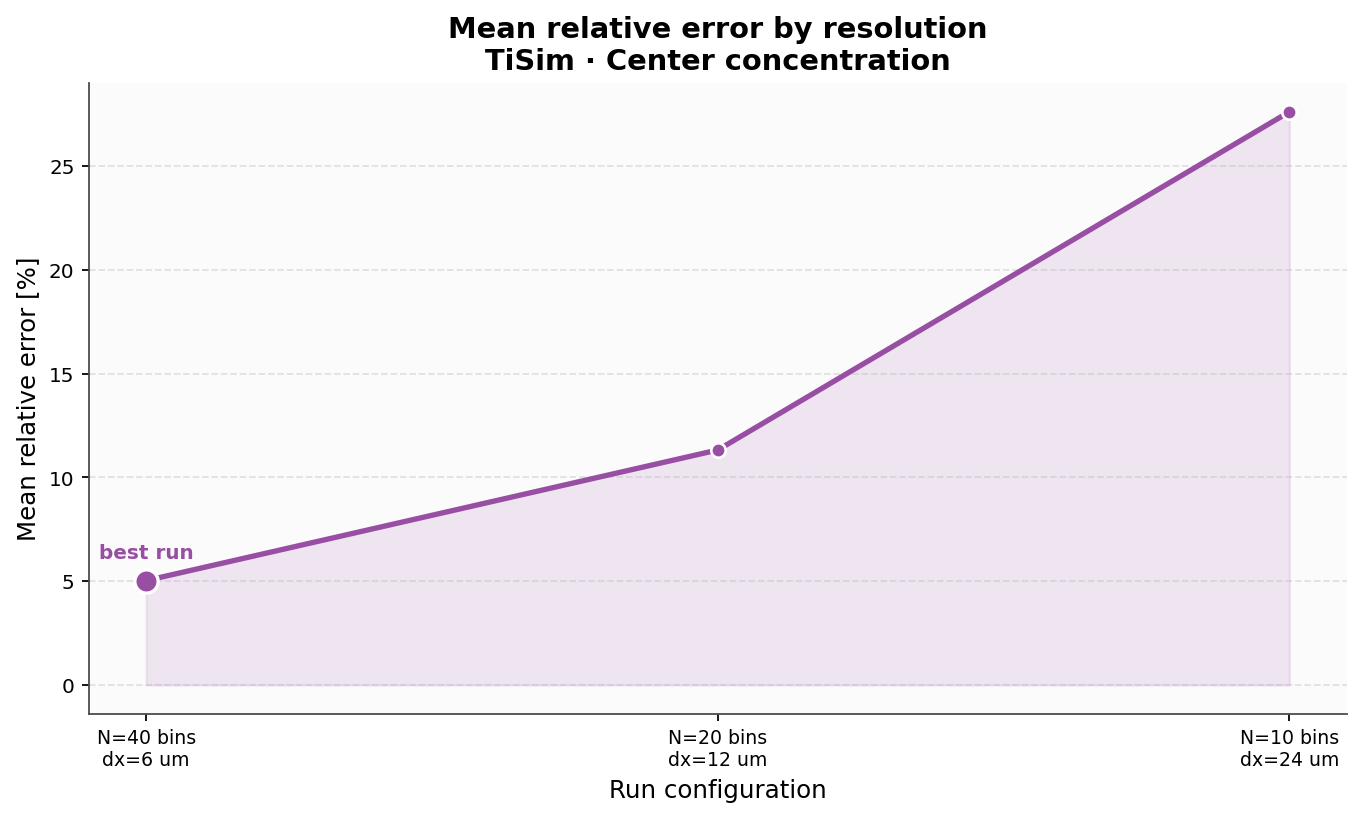

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/SuppMat/SuppMatPlots/diffusion_decay_comparison


In [28]:
tools = sorted(run_metrics['tool'].unique())
metrics = ['average', 'center']

for metric_name in metrics:
    metric_metrics = run_metrics[run_metrics['metric'] == metric_name].copy()

    for tool_name in tools:
        tool_metrics = metric_metrics[metric_metrics['tool'] == tool_name].copy()
        if tool_metrics.empty:
            continue

        tool_metrics = tool_metrics.sort_values(['dx_um', 'dt_min'], na_position='last').reset_index(drop=True)

        tick_labels = tool_metrics['resolution_label'].str.replace(', ', '\n', regex=False)

        x_positions = np.arange(len(tool_metrics))
        y_values = tool_metrics['mean_relative_error_percent']
        best_position = int(y_values.argmin())
        figure_width = 8.4 if len(tool_metrics) <= 4 else 11.2

        fig, axis = plt.subplots(figsize=(figure_width, 5.0), constrained_layout=True)
        axis.plot(
            x_positions,
            y_values,
            color=tool_colors[tool_name],
            linewidth=2.4,
            marker='o',
            markersize=6.5,
            markeredgecolor='white',
            markeredgewidth=1.2,
        )
        axis.fill_between(x_positions, y_values, color=tool_colors[tool_name], alpha=0.12)
        axis.scatter(
            x_positions[best_position],
            y_values.iloc[best_position],
            s=110,
            color=tool_colors[tool_name],
            edgecolor='white',
            linewidth=1.5,
            zorder=3,
        )
        axis.annotate(
            'best run',
            (x_positions[best_position], y_values.iloc[best_position]),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=9,
            color=tool_colors[tool_name],
            fontweight='semibold',
        )

        axis.set_xticks(x_positions)
        axis.set_xticklabels(tick_labels, rotation=0, ha='center')
        axis.tick_params(axis='x', labelsize=8.5)
        axis.set_ylabel('Mean relative error [%]')
        axis.set_xlabel('Run configuration')
        axis.set_title(f'Mean relative error by resolution\n{tool_name} · {metric_titles[metric_name]}')
        axis.margins(x=0.05)
        style_axis(axis)

        save_and_show(fig, f'mean_relative_error_{metric_file_tokens[metric_name]}_{tool_name.lower()}.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 5: Select One Best Average-Concentration Run Per Tool

Select the lowest whole-box-average MAE in each tool family, breaking ties by mean relative error, resolution, time step, and run ID. Use those same runs for both center and average plots and for both error measures.


In [29]:
best_average_runs = (
    run_metrics.loc[run_metrics['metric'] == 'average']
    .sort_values(['tool', 'mean_absolute_error_uM', 'mean_relative_error_percent', 'dx_um', 'dt_min', 'run_id'])
    .drop_duplicates('tool')
)
best_runs = run_metrics.merge(
    best_average_runs[['tool', 'run_id']], on=['tool', 'run_id'], validate='many_to_one',
).sort_values(['metric', 'mean_absolute_error_uM'])
best_runs.to_csv(plot_output_dir / 'best_run_error_metrics.csv', index=False)
best_average_run_ids = best_average_runs[['tool', 'run_id']]
best_comparison = comparison.merge(
    best_average_run_ids, on=['tool', 'run_id'], validate='many_to_one',
).sort_values(['tool', 'metric', 'time_min'])
best_runs


,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,duration_min,first_time_min,last_time_min,relative_point_count,mean_absolute_error_uM,time_weighted_mean_absolute_error_uM,l2_error_uM,max_absolute_error_uM,mean_relative_error_percent,time_weighted_mean_relative_error_percent,l2_relative_error_percent,max_relative_error_percent
3,average,PhysiCell,PhysiCell_dx_5um,5.00000,NaN,voxel size=5 um,1001.0,10.0000,0.0,10.0000,1001.0,0.067874,0.067905,0.069746,0.074369,0.984049,0.984491,1.013727,1.084400
1,average,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",1001.0,10.0000,0.0,10.0000,1001.0,0.186791,0.186880,0.188729,0.195607,2.696681,2.697951,2.733198,2.852234
2,average,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.0001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min",100.0,9.9001,0.0,9.9001,100.0,0.196892,0.197821,0.200564,0.209715,2.845969,2.859274,2.907932,3.057939
0,average,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",10000.0,9.9990,0.0,9.9990,10000.0,0.256956,0.256968,0.260234,0.271531,3.713181,3.713355,3.772463,3.959308
4,average,TiSim,TiSim_N_40,6.00000,NaN,"N=40 bins, dx=6 um",201.0,9.9840,0.0,9.9840,201.0,0.305405,0.306510,0.311679,0.326165,4.418433,4.434290,4.522545,4.755954
6,center,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",1001.0,10.0000,0.0,10.0000,1001.0,0.001865,0.001867,0.002846,0.010910,0.050801,0.050833,0.060780,0.169100
8,center,PhysiCell,PhysiCell_dx_5um,5.00000,NaN,voxel size=5 um,1001.0,10.0000,0.0,10.0000,1001.0,0.035132,0.035146,0.037441,0.042178,1.247223,1.247709,1.343393,1.522734
7,center,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.0001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min",100.0,9.9001,0.0,9.9001,100.0,0.079003,0.079336,0.083657,0.092213,2.801123,2.812610,2.990266,3.329127
5,center,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",10000.0,9.9990,0.0,9.9990,10000.0,0.116082,0.116087,0.122033,0.133821,4.111129,4.111298,4.358750,4.831289
9,center,TiSim,TiSim_N_40,6.00000,NaN,"N=40 bins, dx=6 um",201.0,9.9840,0.0,9.9840,201.0,0.142057,0.142369,0.149369,0.163525,5.028935,5.036417,5.332430,5.903686


In [30]:
# Shared plotting code for absolute and relative errors of the same selected runs.
def plot_best_run_errors(error_kind):
    absolute = error_kind == 'absolute'
    title = 'Absolute' if absolute else 'Relative'
    unit = 'uM' if absolute else '%'
    point_column = 'absolute_error_uM' if absolute else 'relative_error_percent'
    mean_column = f'mean_{point_column}'
    value_format = '.3f' if absolute else '.2f'
    bar_prefix = 'best_absolute_resolution' if absolute else 'best_resolution'

    for metric_name in ['average', 'center']:
        metric_best = best_runs.loc[best_runs['metric'] == metric_name].sort_values(mean_column)
        fig, axis = plt.subplots(figsize=(8.4, 4.9), constrained_layout=True)
        bars = axis.bar(
            metric_best['tool'], metric_best[mean_column], width=0.65,
            color=[tool_colors[tool] for tool in metric_best['tool']],
            edgecolor='white', linewidth=1.5,
        )
        maximum = metric_best[mean_column].max()
        for bar, (_, row) in zip(bars, metric_best.iterrows()):
            resolution_text = row['resolution_label'].replace(', ', '\n')
            axis.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03 * maximum,
                f"{row[mean_column]:{value_format}} {unit}\n{resolution_text}",
                ha='center', va='bottom', fontsize=8.8,
            )
        axis.set_ylabel(f'Mean {error_kind} error [{unit}]')
        axis.set_xlabel('Tool')
        axis.set_title(f'Average-selected runs: mean {error_kind} error\n{metric_titles[metric_name]}')
        axis.set_ylim(0, maximum * (1.24 if absolute else 1.22))
        style_axis(axis)
        save_and_show(fig, f'{bar_prefix}_{metric_file_tokens[metric_name]}.png')

    for metric_name in ['average', 'center']:
        metric_comparison = best_comparison.loc[best_comparison['metric'] == metric_name]
        fig, axis = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)
        for tool_name, group in metric_comparison.groupby('tool'):
            group = group.sort_values('time_min')
            axis.plot(
                group['time_min'], group[point_column], color=tool_colors[tool_name],
                linewidth=2.4, marker='o', markersize=4.8, markeredgecolor='white',
                markeredgewidth=0.8, markevery=max(len(group) // 18, 1),
                label=f"{tool_name}: {group['resolution_label'].iloc[0]}",
            )
        axis.set_xlabel('Time [min]')
        axis.set_ylabel(f'{title} error [{unit}]')
        axis.set_title(f'{title} error over time for the best run of each tool\n{metric_titles[metric_name]}')
        style_axis(axis)
        axis.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d9d9df')
        save_and_show(fig, f'{error_kind}_error_over_time_{metric_file_tokens[metric_name]}.png')

    print(f'Saved standalone plots to {plot_output_dir}')


## Step 6: Plot Absolute Error For The Average-Selected Runs

Use the same selected run per tool for both concentration measures.


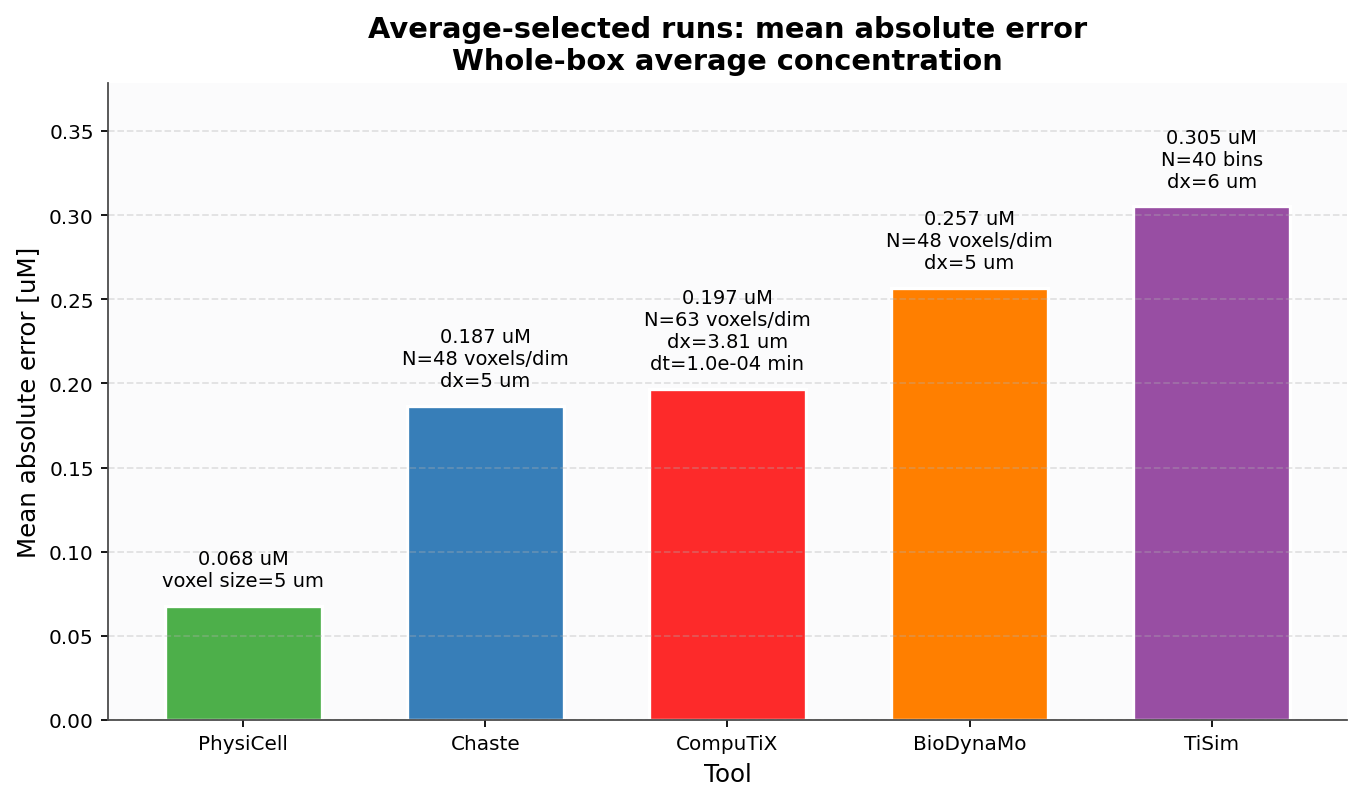

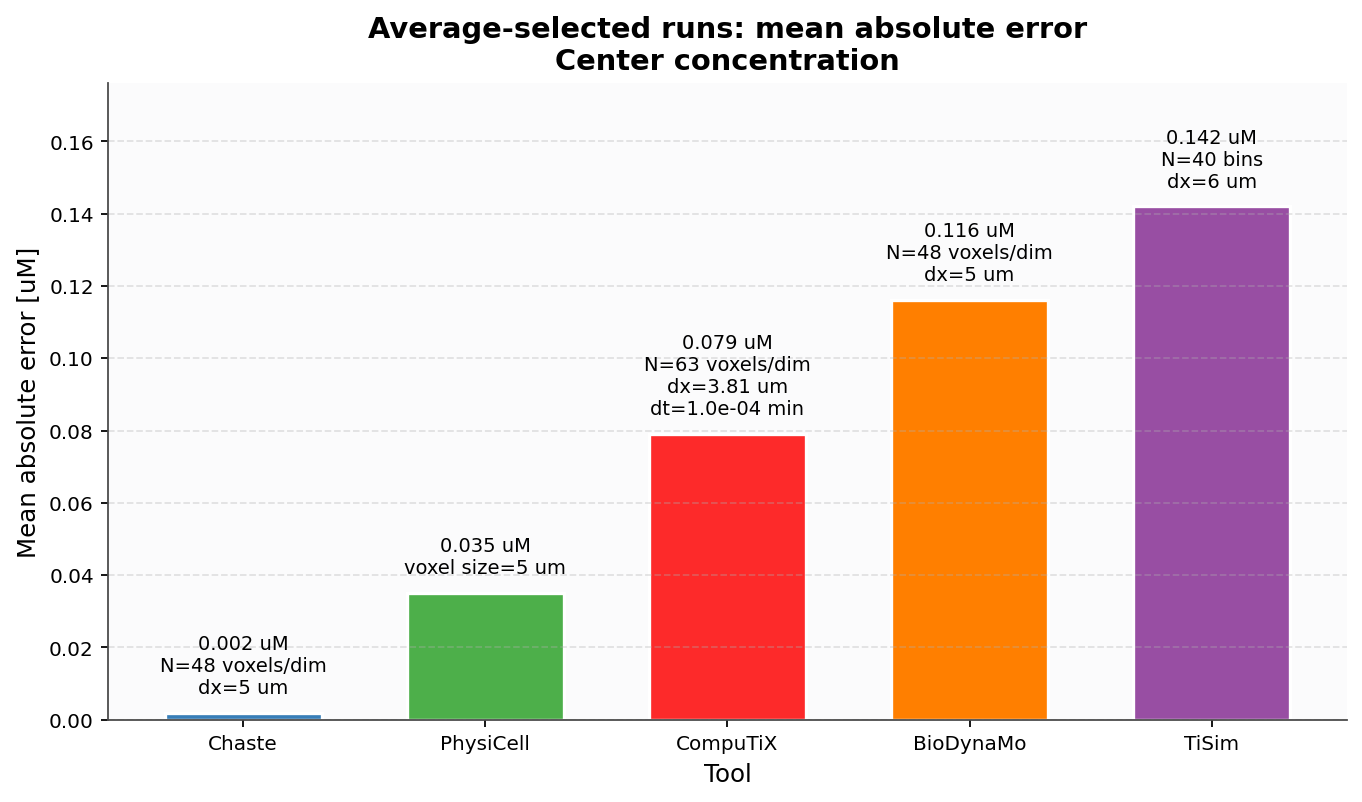

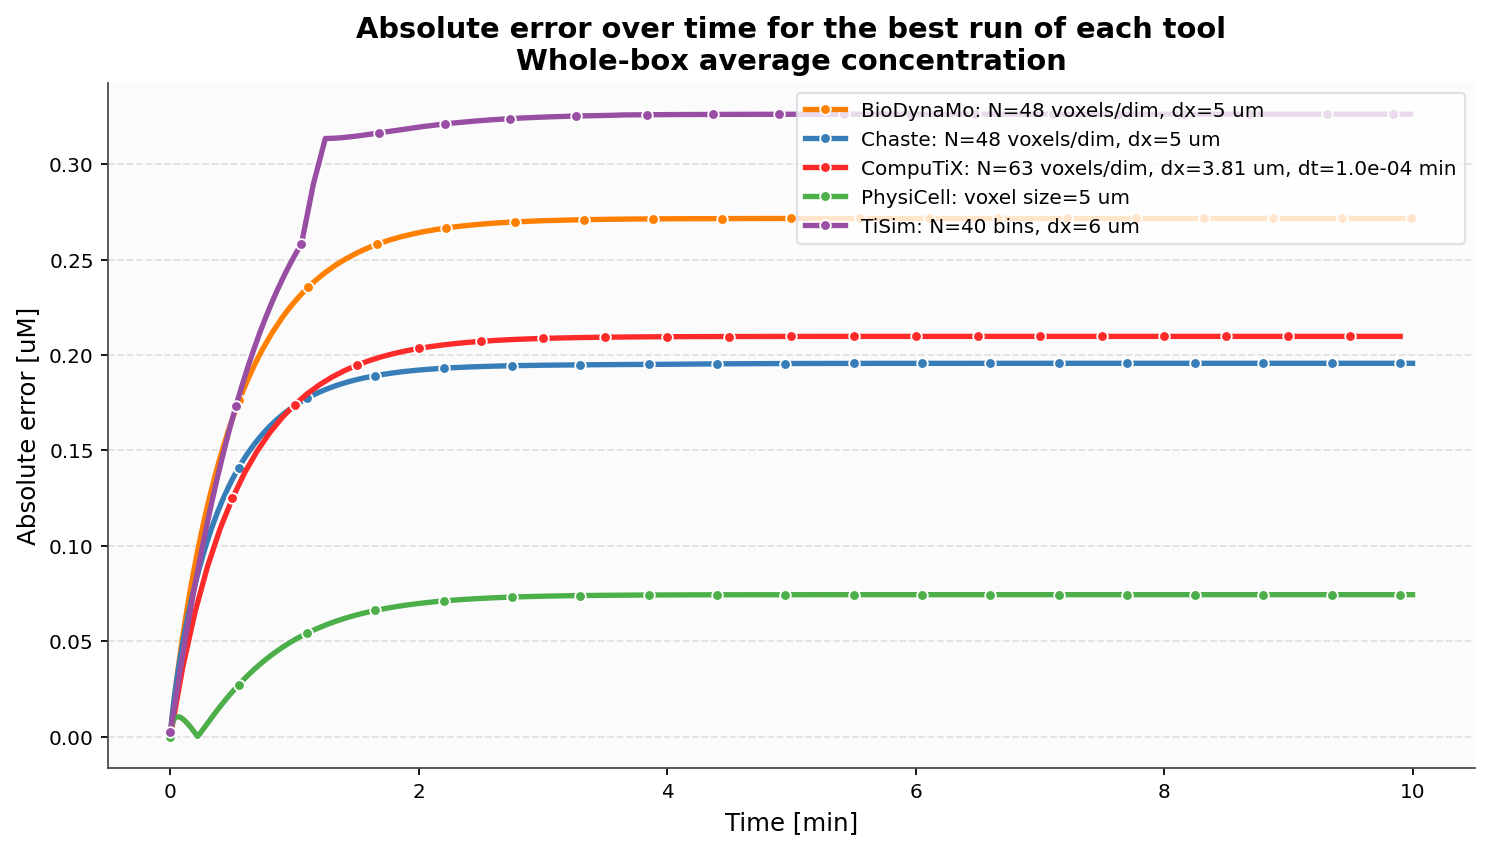

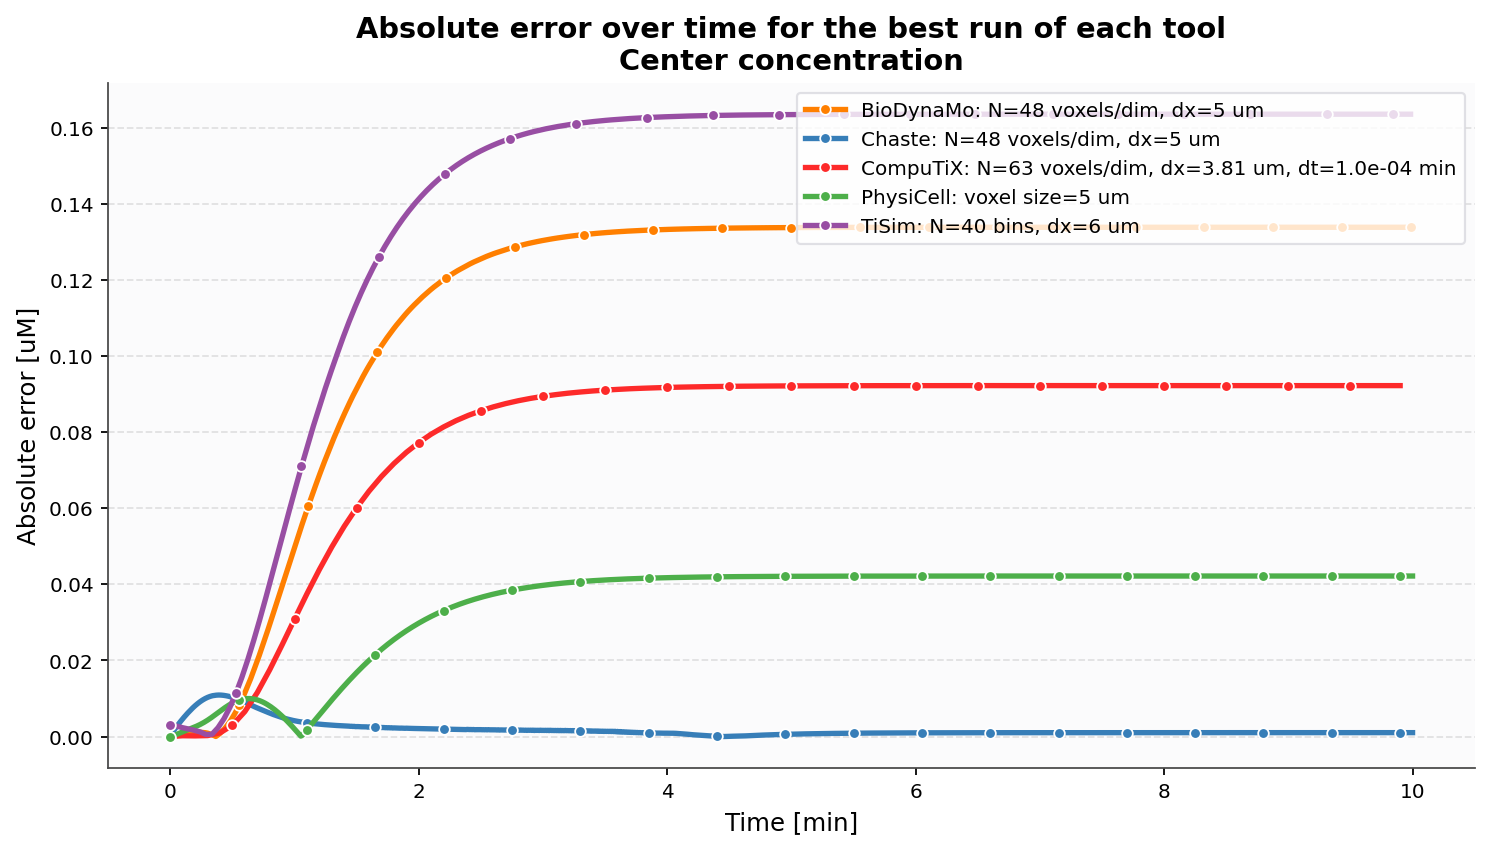

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/SuppMat/SuppMatPlots/diffusion_decay_comparison


In [31]:
plot_best_run_errors('absolute')


## Step 7: Plot Relative Error For The Average-Selected Runs

Use the same selected run per tool for both concentration measures.


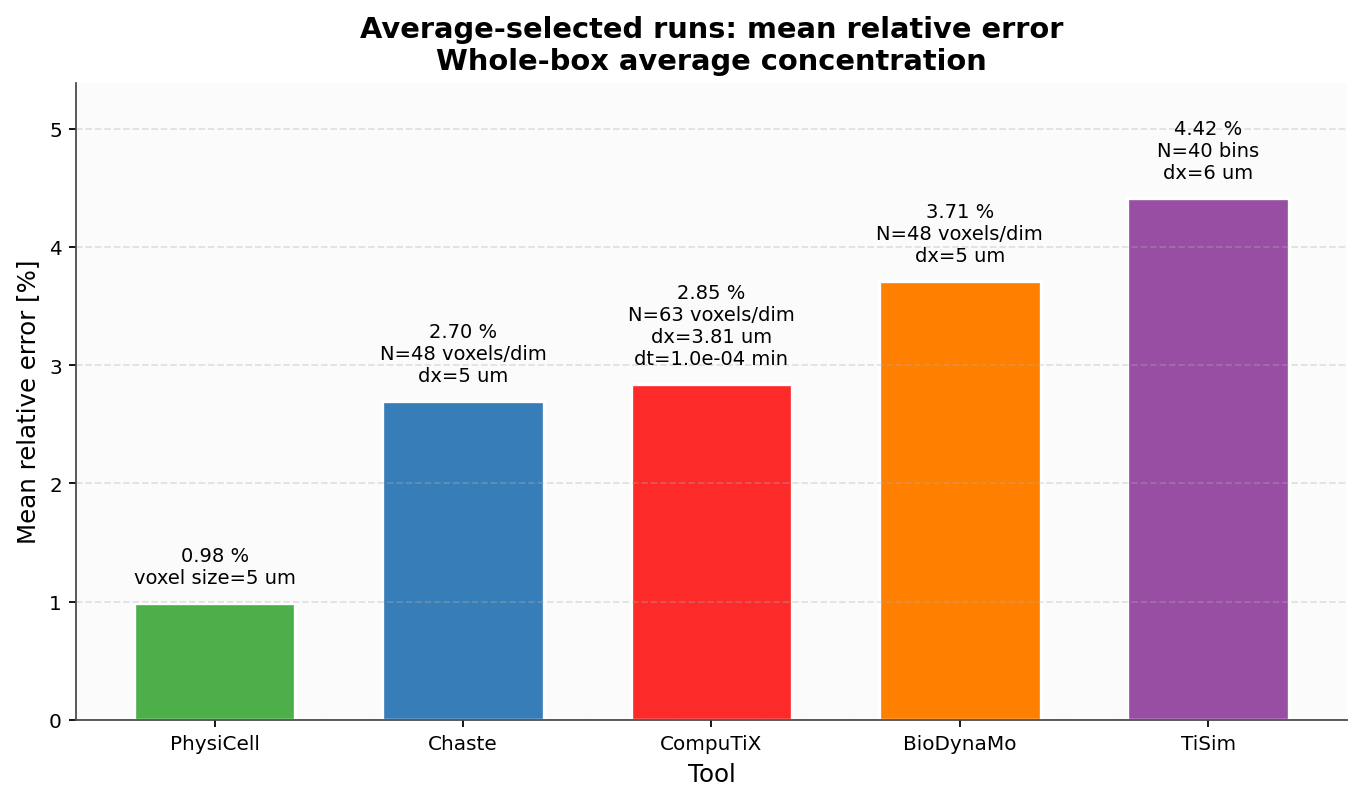

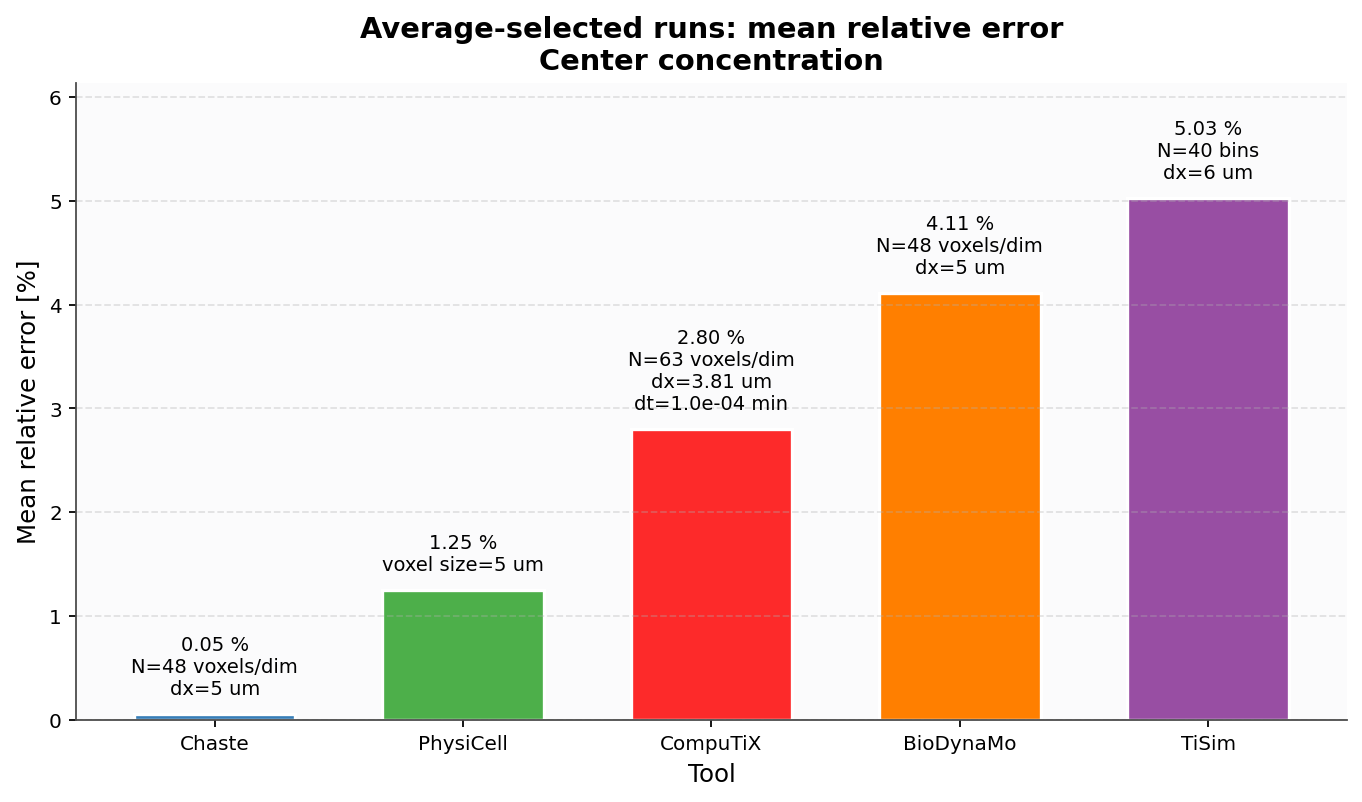

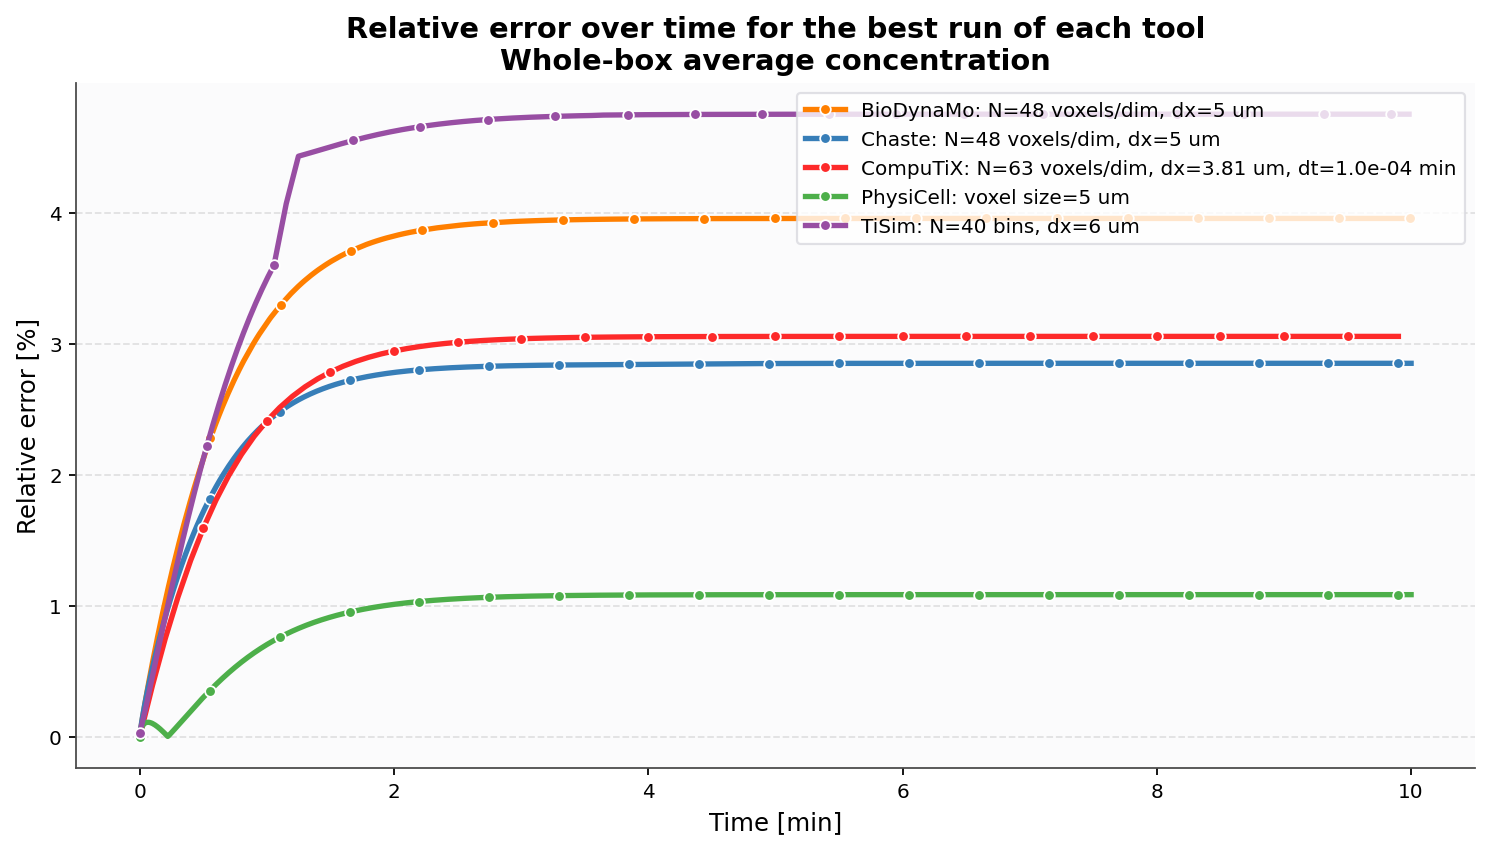

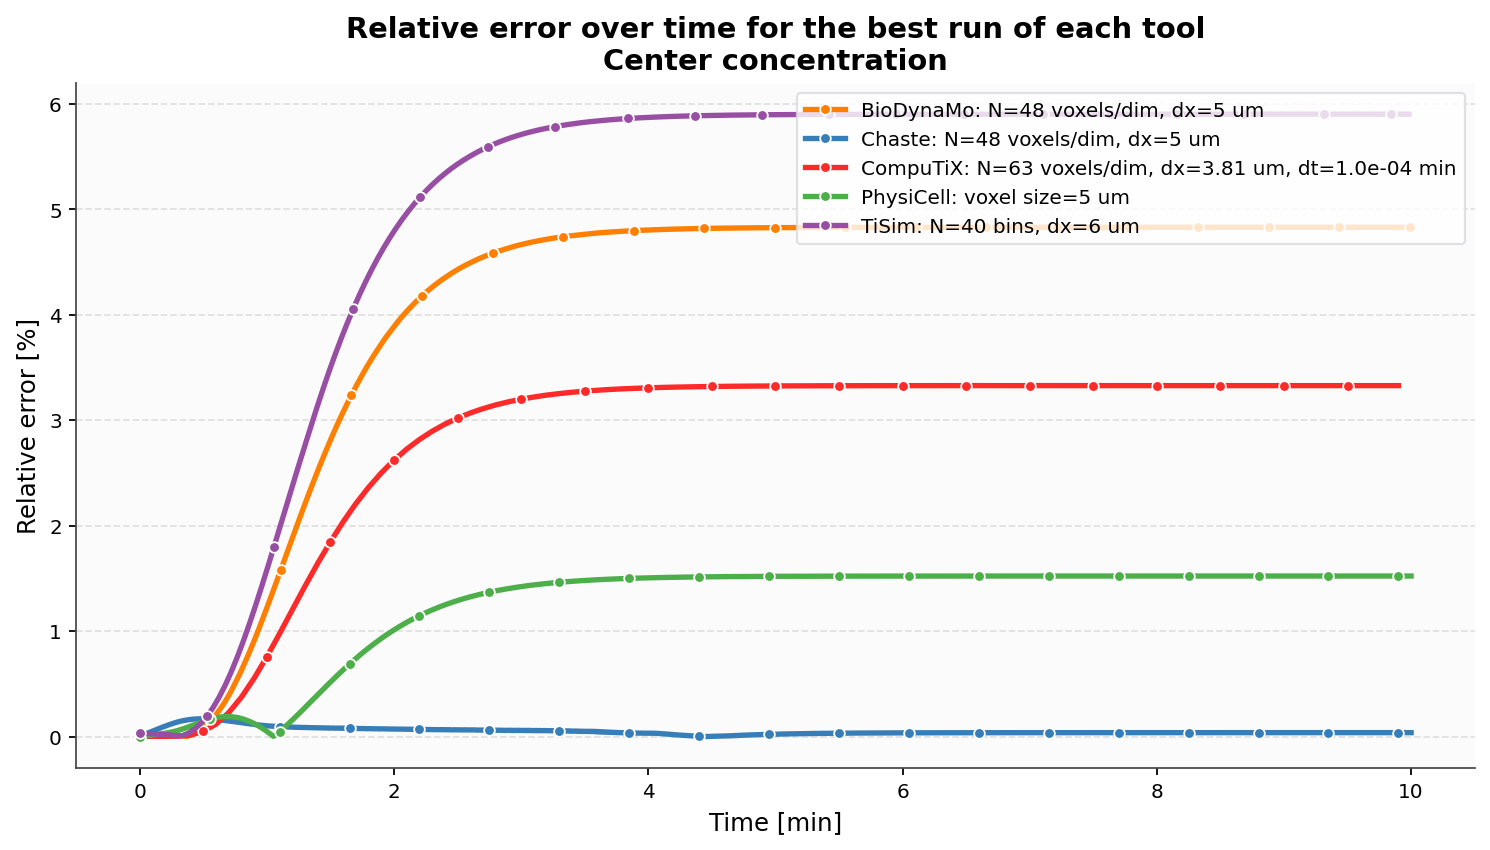

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/SuppMat/SuppMatPlots/diffusion_decay_comparison


In [32]:
plot_best_run_errors('relative')


## Step 8: Nature-Style Concentration And Relative Error

The selected average-concentration run from each tool is plotted against the analytical diffusion-decay solution. The combined figure shows concentration first, then relative error for those same runs. Individual full-time and zoomed concentration plots are retained.


In [33]:
nature_plot_dir = ROOT / 'ResultAnalysis' / 'plots' / 'diffusion_decay'
nature_plot_dir.mkdir(parents=True, exist_ok=True)

# Same colorblind-friendly palette as diffusion_single_paper.ipynb, extended with the analytical reference
nature_colors = dict(tool_colors)
nature_colors['Analytical'] = '#000000'

nature_linestyles = {tool: '-' for tool in tool_colors}
nature_linestyles['Analytical'] = '--'

nature_linewidths = {'Analytical': 2.0}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial', 'sans-serif'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'figure.dpi': 400,
})

# Reuse the selected average samples for concentration and error plots.
best_average_errors = best_comparison.loc[best_comparison['metric'] == 'average']

tool_series = {
    tool_name: group.reset_index(drop=True)
    for tool_name, group in best_average_errors.groupby('tool')
}

analytical_series = (
    analytical_df[['time_min', 'analytical_average_uM']]
    .sort_values('time_min')
    .reset_index(drop=True)
)


def _nature_plot_entries():
    entries = [
        (tool_name, tool_series[tool_name], tool_series[tool_name]['average_uM'])
        for tool_name in tools
        if tool_name in tool_series
    ]
    entries.append(('Analytical', analytical_series, analytical_series['analytical_average_uM']))
    return entries


def create_nature_plot(data, xlim=None, ylim=None, title=None, filename=None, markers=False, figsize=(3, 3)):
    fig, ax = plt.subplots(figsize=figsize, dpi=400)

    for label, df, y in data:
        x = df['time_min']
        ax.plot(
            x, y,
            color=nature_colors[label],
            linestyle=nature_linestyles[label],
            linewidth=nature_linewidths.get(label, 1.8),
            alpha=0.7,
            label=label,
        )
        if markers:
            ax.plot(x[::5], y.iloc[::5], 'o', color=nature_colors[label], markersize=4, alpha=0.7)

    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)

    ax.set_xlabel("Time (min)", fontsize=9, labelpad=4)
    ax.set_ylabel("Concentration (μM)", fontsize=9, labelpad=4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if title:
        ax.text(-0.18, 1.1, title, transform=ax.transAxes, fontsize=11, fontweight='bold')

    plt.tight_layout(rect=[0.06, 0.06, 1, 0.97])
    plt.subplots_adjust(left=0.08, top=0.97, hspace=0.45, wspace=0.3)

    if filename:
        fig.savefig(nature_plot_dir / f"{filename}.png", format='png', bbox_inches='tight', pad_inches=0.2, dpi=600)

    plt.show()
    plt.close(fig)


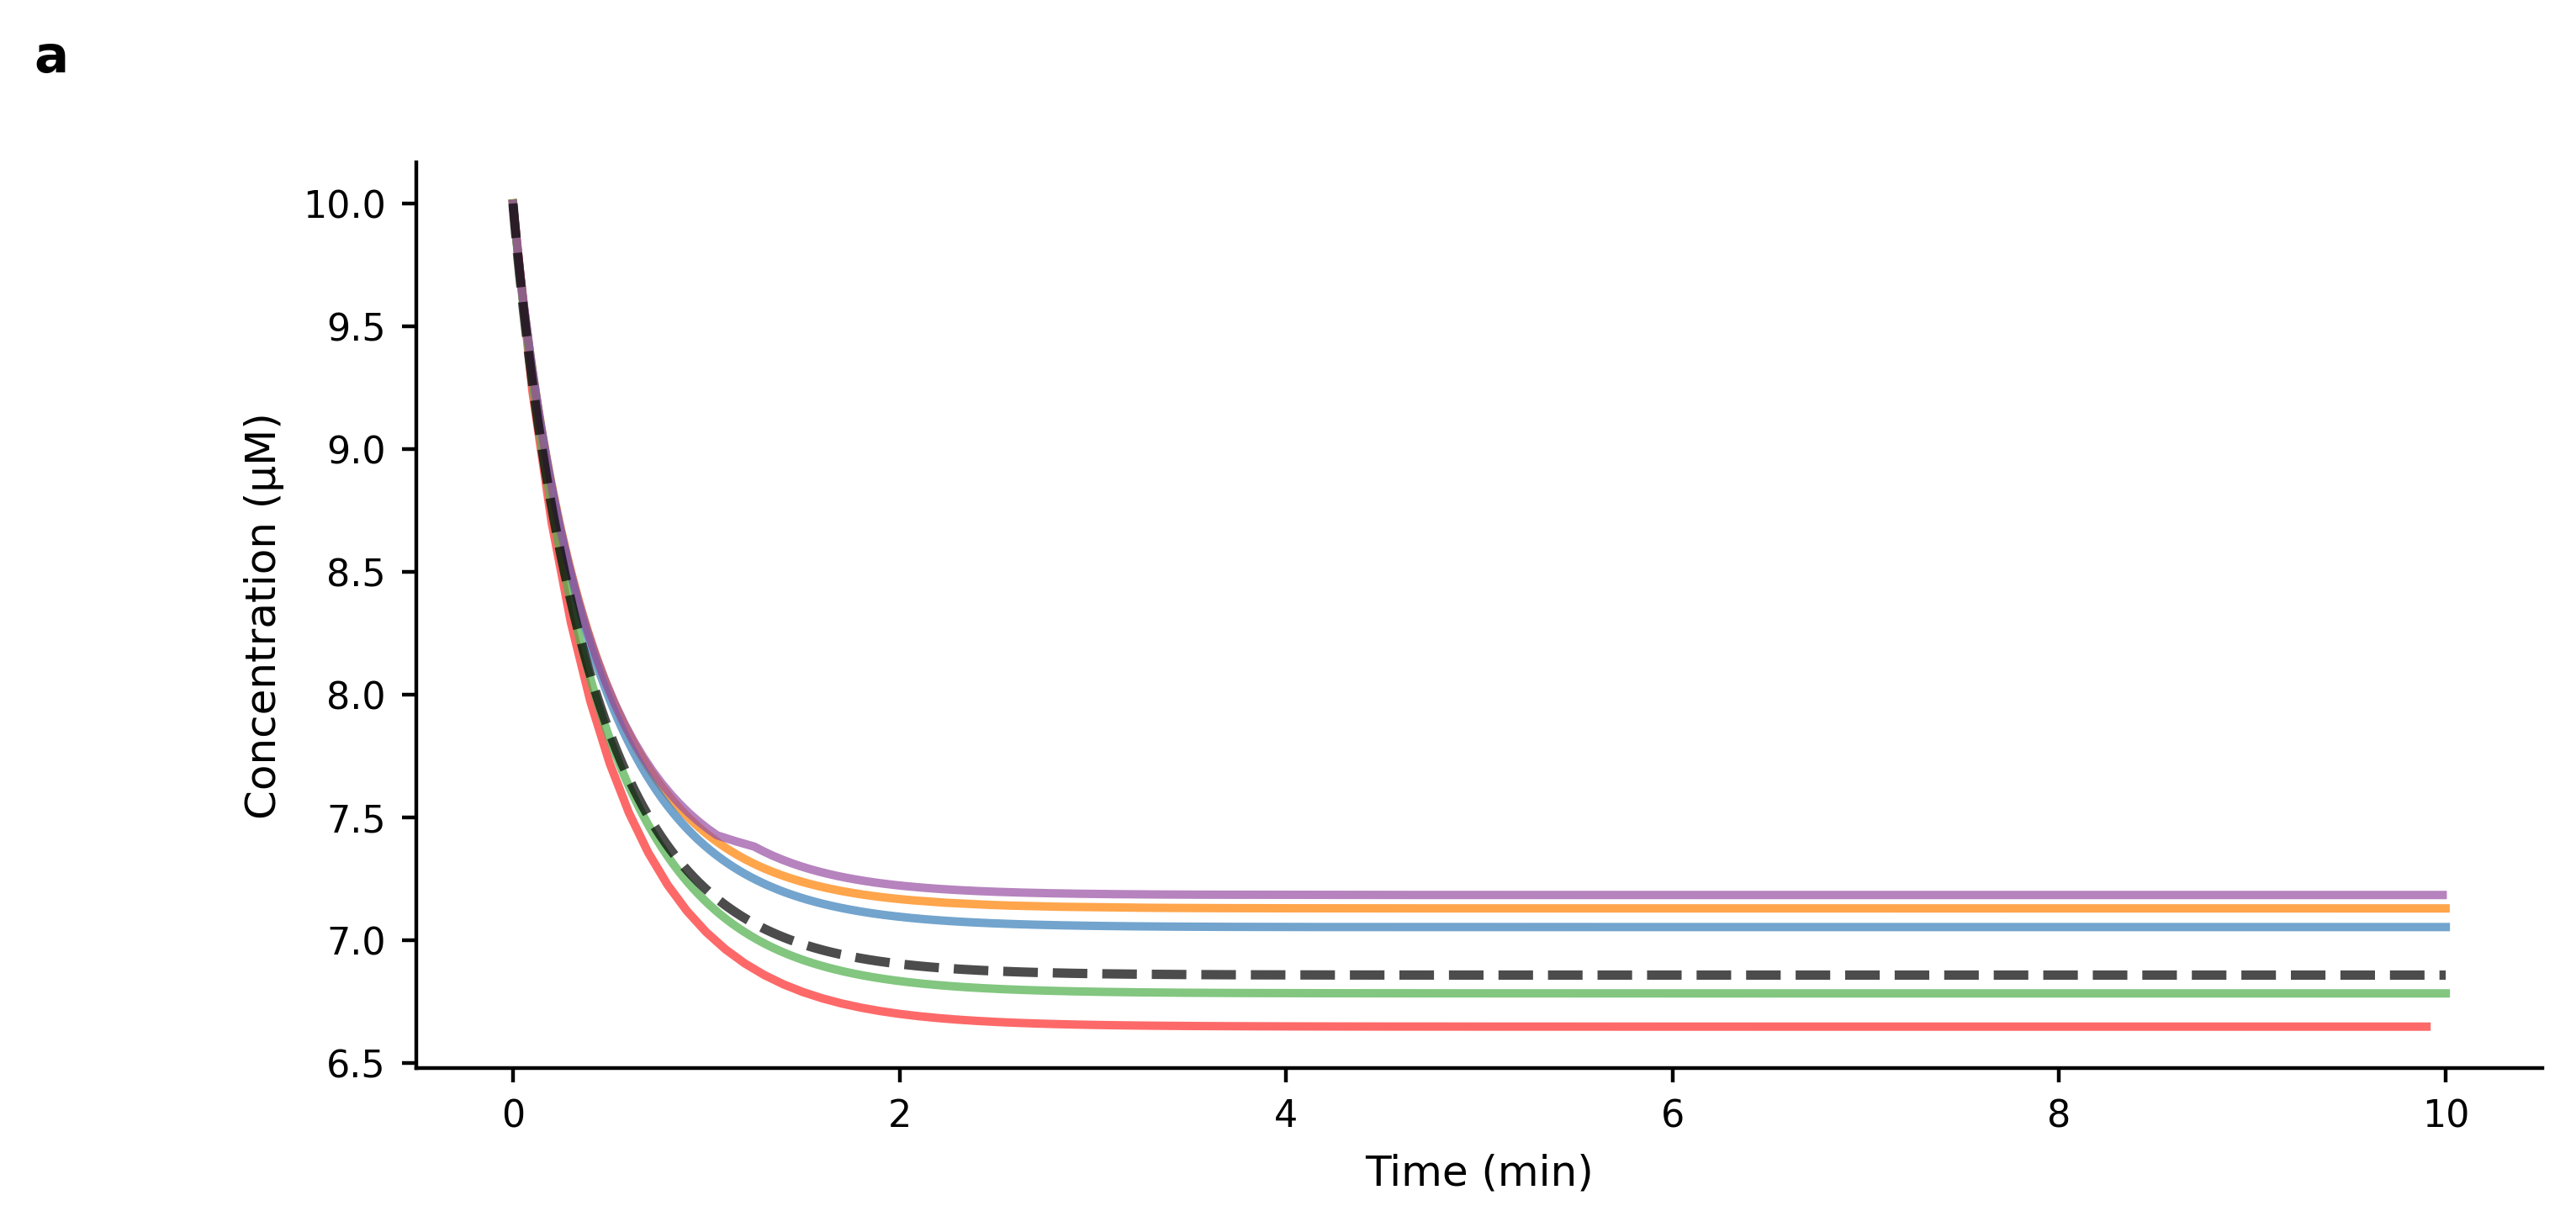

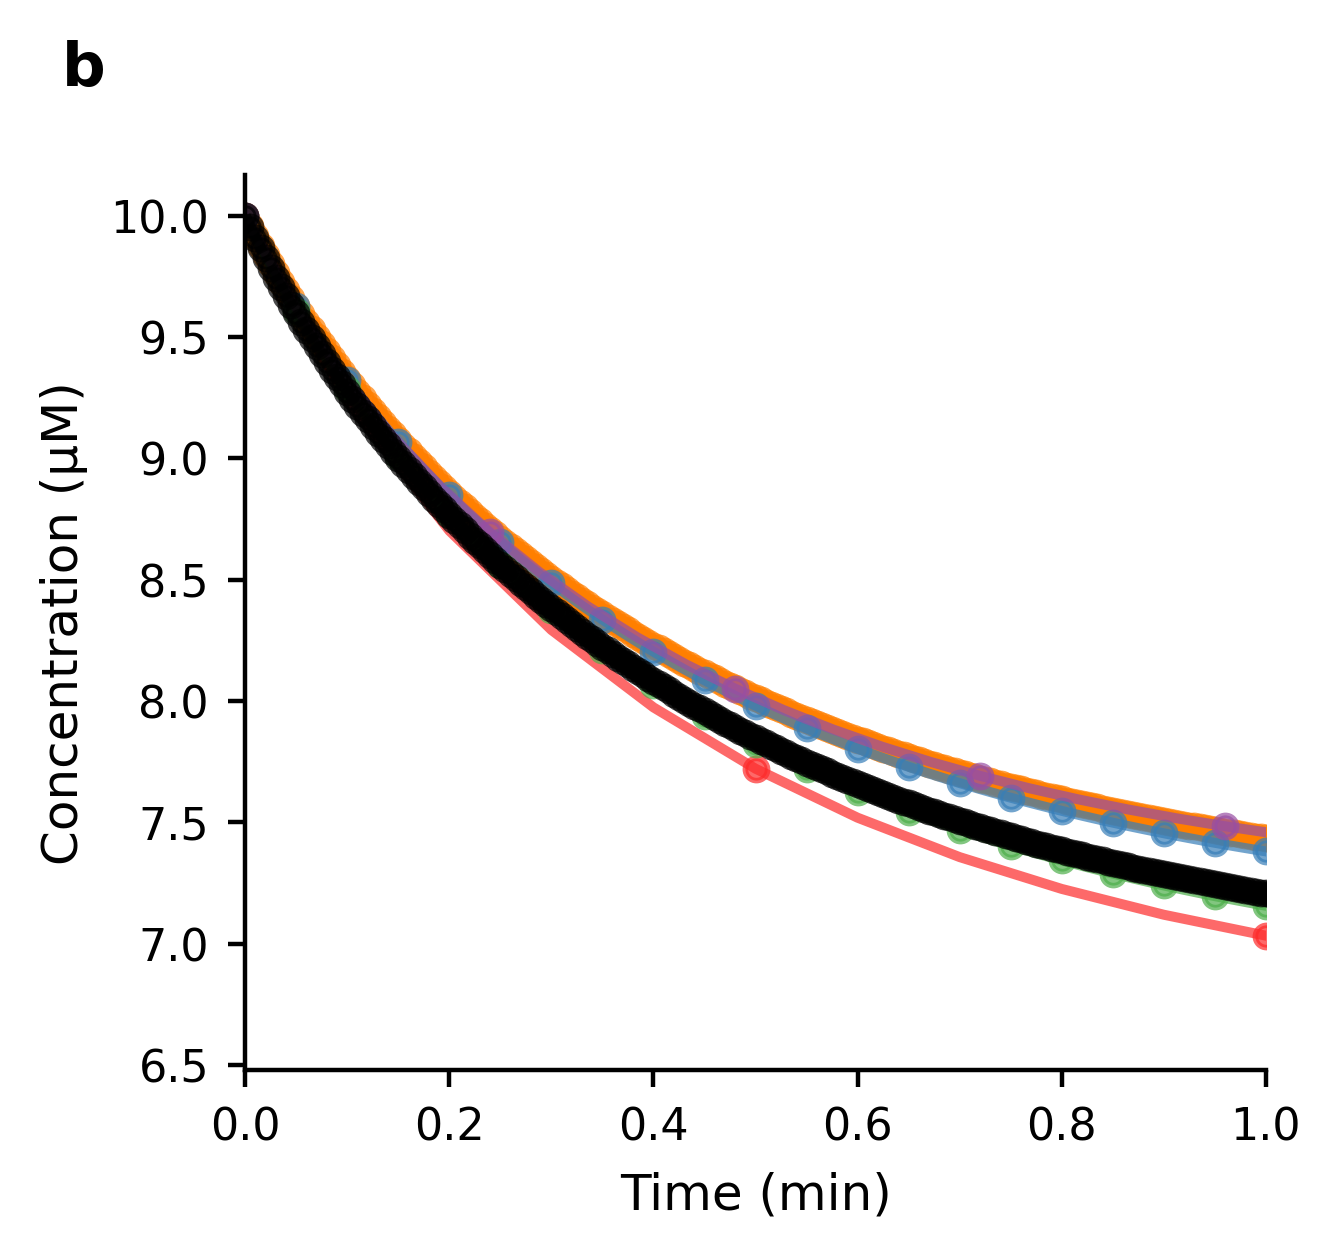

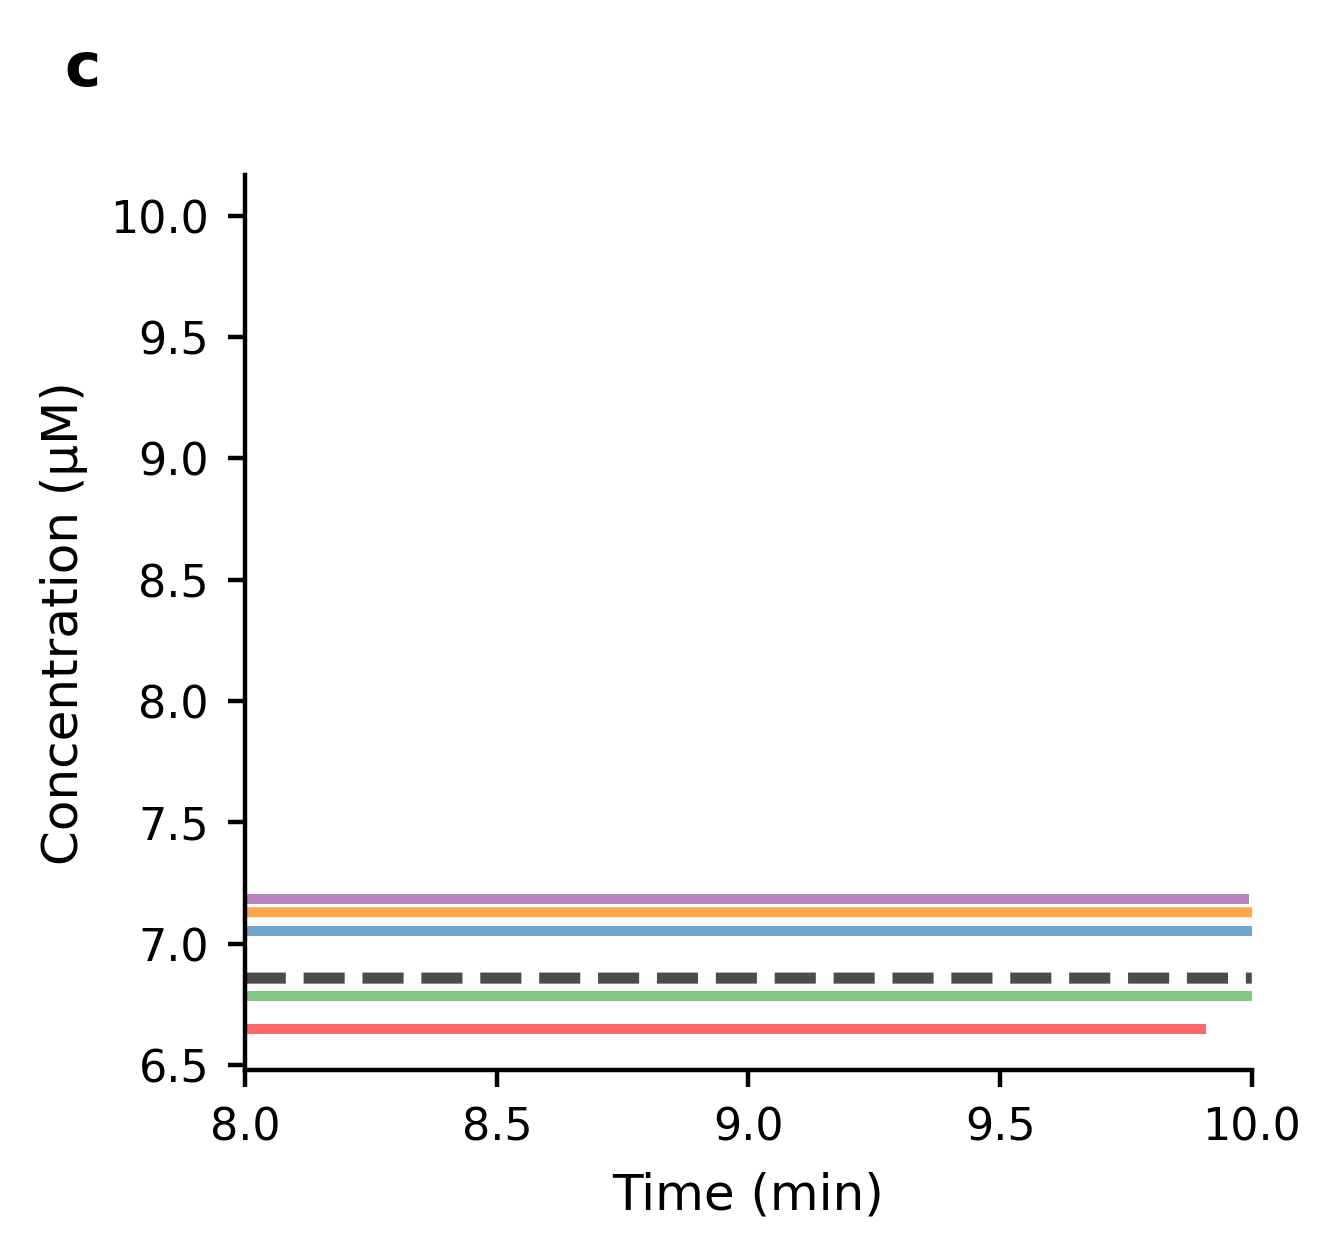

In [34]:
# Panel a: full time course, panel b: early-time zoom (fast decay), panel c: late-time zoom (plateau)
create_nature_plot(_nature_plot_entries(), title='a', filename='decay_full_time', figsize=(7, 3.5))

create_nature_plot(_nature_plot_entries(), xlim=(0, 1), title='b', filename='decay_early_time', markers=True)

create_nature_plot(_nature_plot_entries(), xlim=(8, 10), title='c', filename='decay_late_time', markers=False)


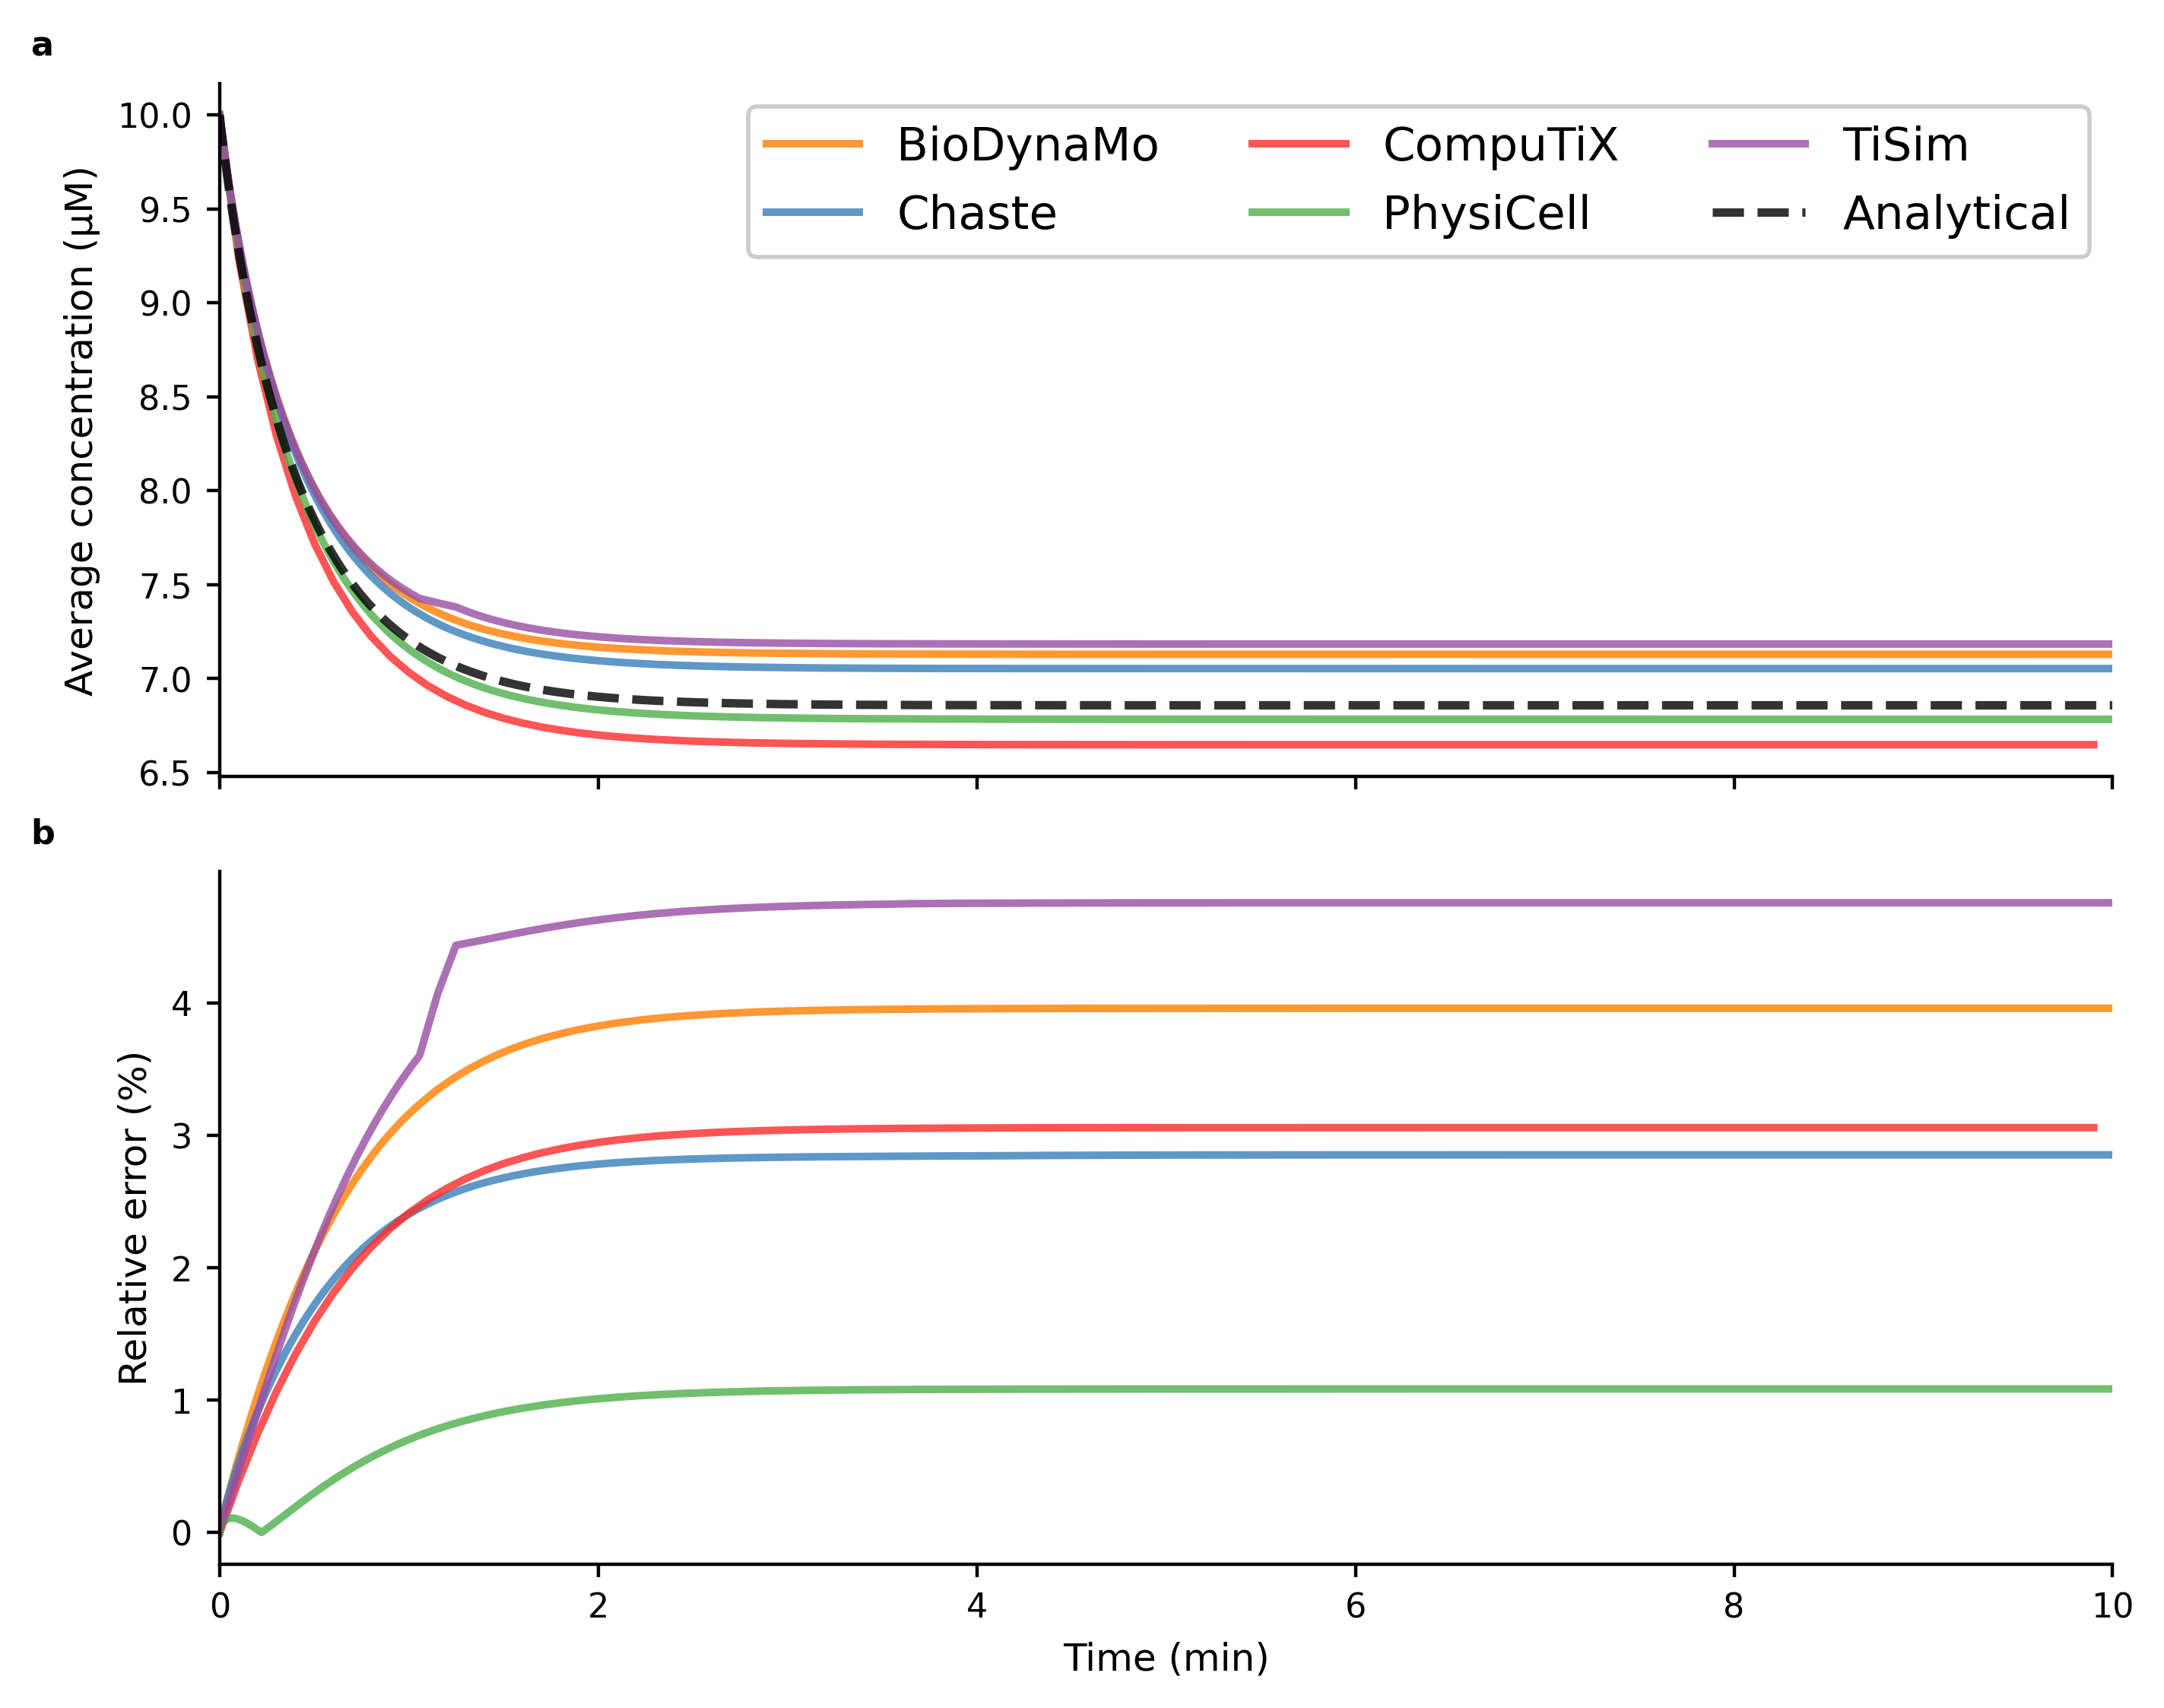

In [43]:
def create_nature_complete_plot():
    fig, axes = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True, constrained_layout=True)
    ax_full, ax_error = axes

    for label, df, y in _nature_plot_entries():
        ax_full.plot(
            df['time_min'], y, label=label,
            color=nature_colors[label], linestyle=nature_linestyles[label],
            linewidth=nature_linewidths.get(label, 1.8), alpha=0.8,
        )
    for tool_name, group in best_average_errors.groupby('tool'):
        group = group.sort_values('time_min')
        ax_error.plot(
            group['time_min'], group['relative_error_percent'],
            color=nature_colors[tool_name], linewidth=1.8, alpha=0.8,
        )
    
    ax_full.set_ylabel('Average concentration (μM)')
    ax_error.set_ylabel('Relative error (%)')
    ax_error.set_xlabel('Time (min)')
    # ax_error.set_ylim(0, 0)
    ax_full.set_xlim(0, 10)
    for label, axis in zip(['a', 'b'], axes):
        axis.text(-0.1, 1.04, label, transform=axis.transAxes, fontweight='bold')
        axis.spines['top'].set_visible(False)
        axis.spines['right'].set_visible(False)
    ax_full.legend(loc='upper right', ncol=3,  frameon=True, framealpha=1.0, fontsize=11)
    
    fig.savefig(nature_plot_dir / 'decay_nature_style_combined.svg', bbox_inches='tight')
    fig.savefig(nature_plot_dir / 'decay_nature_style_combined.png', bbox_inches='tight', dpi=600)
    plt.show()
    plt.close(fig)


create_nature_complete_plot()


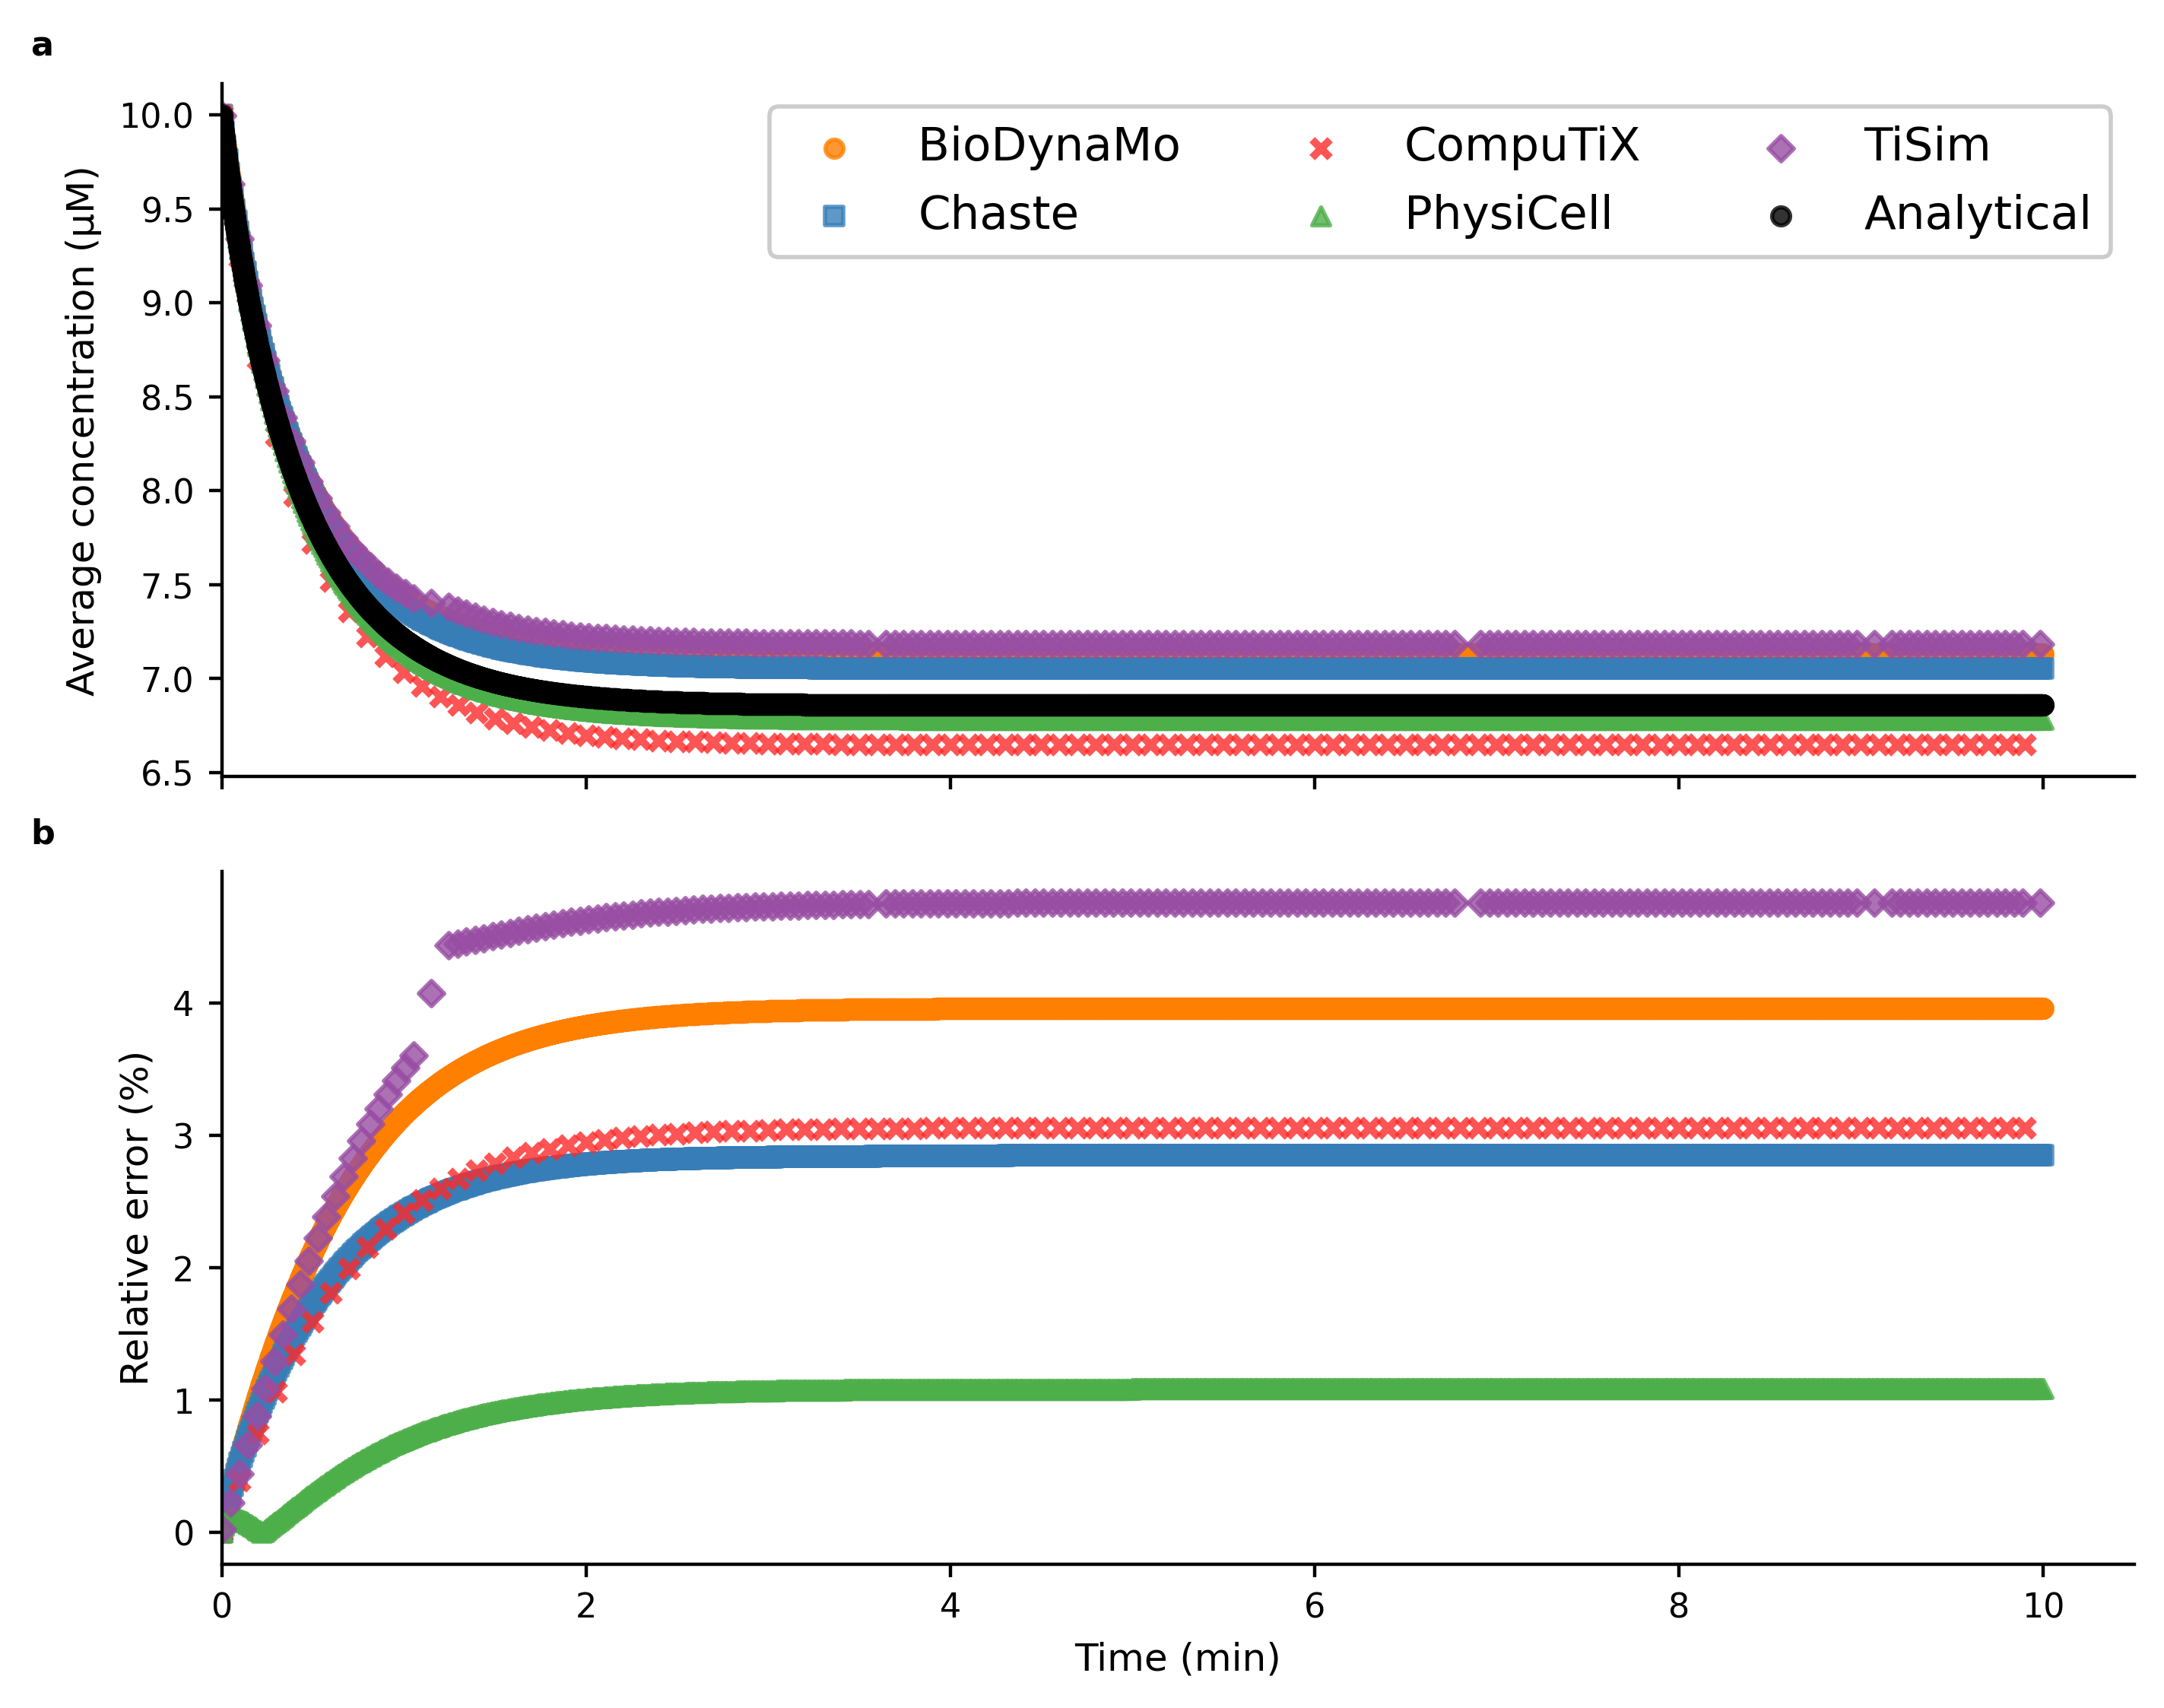

In [39]:
def create_nature_complete_plot():
    fig, axes = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True, constrained_layout=True)
    ax_full, ax_error = axes
    legacy_markers = {
        'BioDynaMo': 'o',
        'Chaste': 's',
        'PhysiCell': '^',
        'TiSim': 'D',
        'CompuTiX': 'x',
    }
    for label, df, y in _nature_plot_entries():
        ax_full.scatter(
            df['time_min'], y, label=label,
            color=nature_colors[label], marker=legacy_markers.get(label, 'o'),
            s=18, alpha=0.8,
        )
    for tool_name, group in best_average_errors.groupby('tool'):
        group = group.sort_values('time_min')
        ax_error.scatter(
            group['time_min'], group['relative_error_percent'],
            color=nature_colors[tool_name], marker=legacy_markers.get(tool_name, 'o'),
            s=18, alpha=0.8, label=tool_name,
        )

    ax_full.set_ylabel('Average concentration (μM)')
    ax_error.set_ylabel('Relative error (%)')
    ax_error.set_xlabel('Time (min)')
    ax_full.set_xlim(left=0.0)
    ax_error.set_xlim(left=0.0)
    for label, axis in zip(['a', 'b'], axes):
        axis.text(-0.1, 1.04, label, transform=axis.transAxes, fontweight='bold')
        axis.spines['top'].set_visible(False)
        axis.spines['right'].set_visible(False)
    ax_full.legend(loc='upper right', ncol=3, frameon=True, framealpha=1.0, fontsize=11)

    fig.savefig(nature_plot_dir / 'decay_nature_style_combined_markers.svg', bbox_inches='tight')
    fig.savefig(nature_plot_dir / 'decay_nature_style_combined_markers.png', bbox_inches='tight', dpi=600)
    plt.show()
    plt.close(fig)


create_nature_complete_plot()


## Step 9: Legacy Center-Concentration Figures

Recreate the center-concentration line and scatter figures from `plot_diffusion_single_ut.py` using the average-selected run for each tool. Figures are saved under `SuppMat/SuppMatPlots/diffusion_single_ut_plots`.

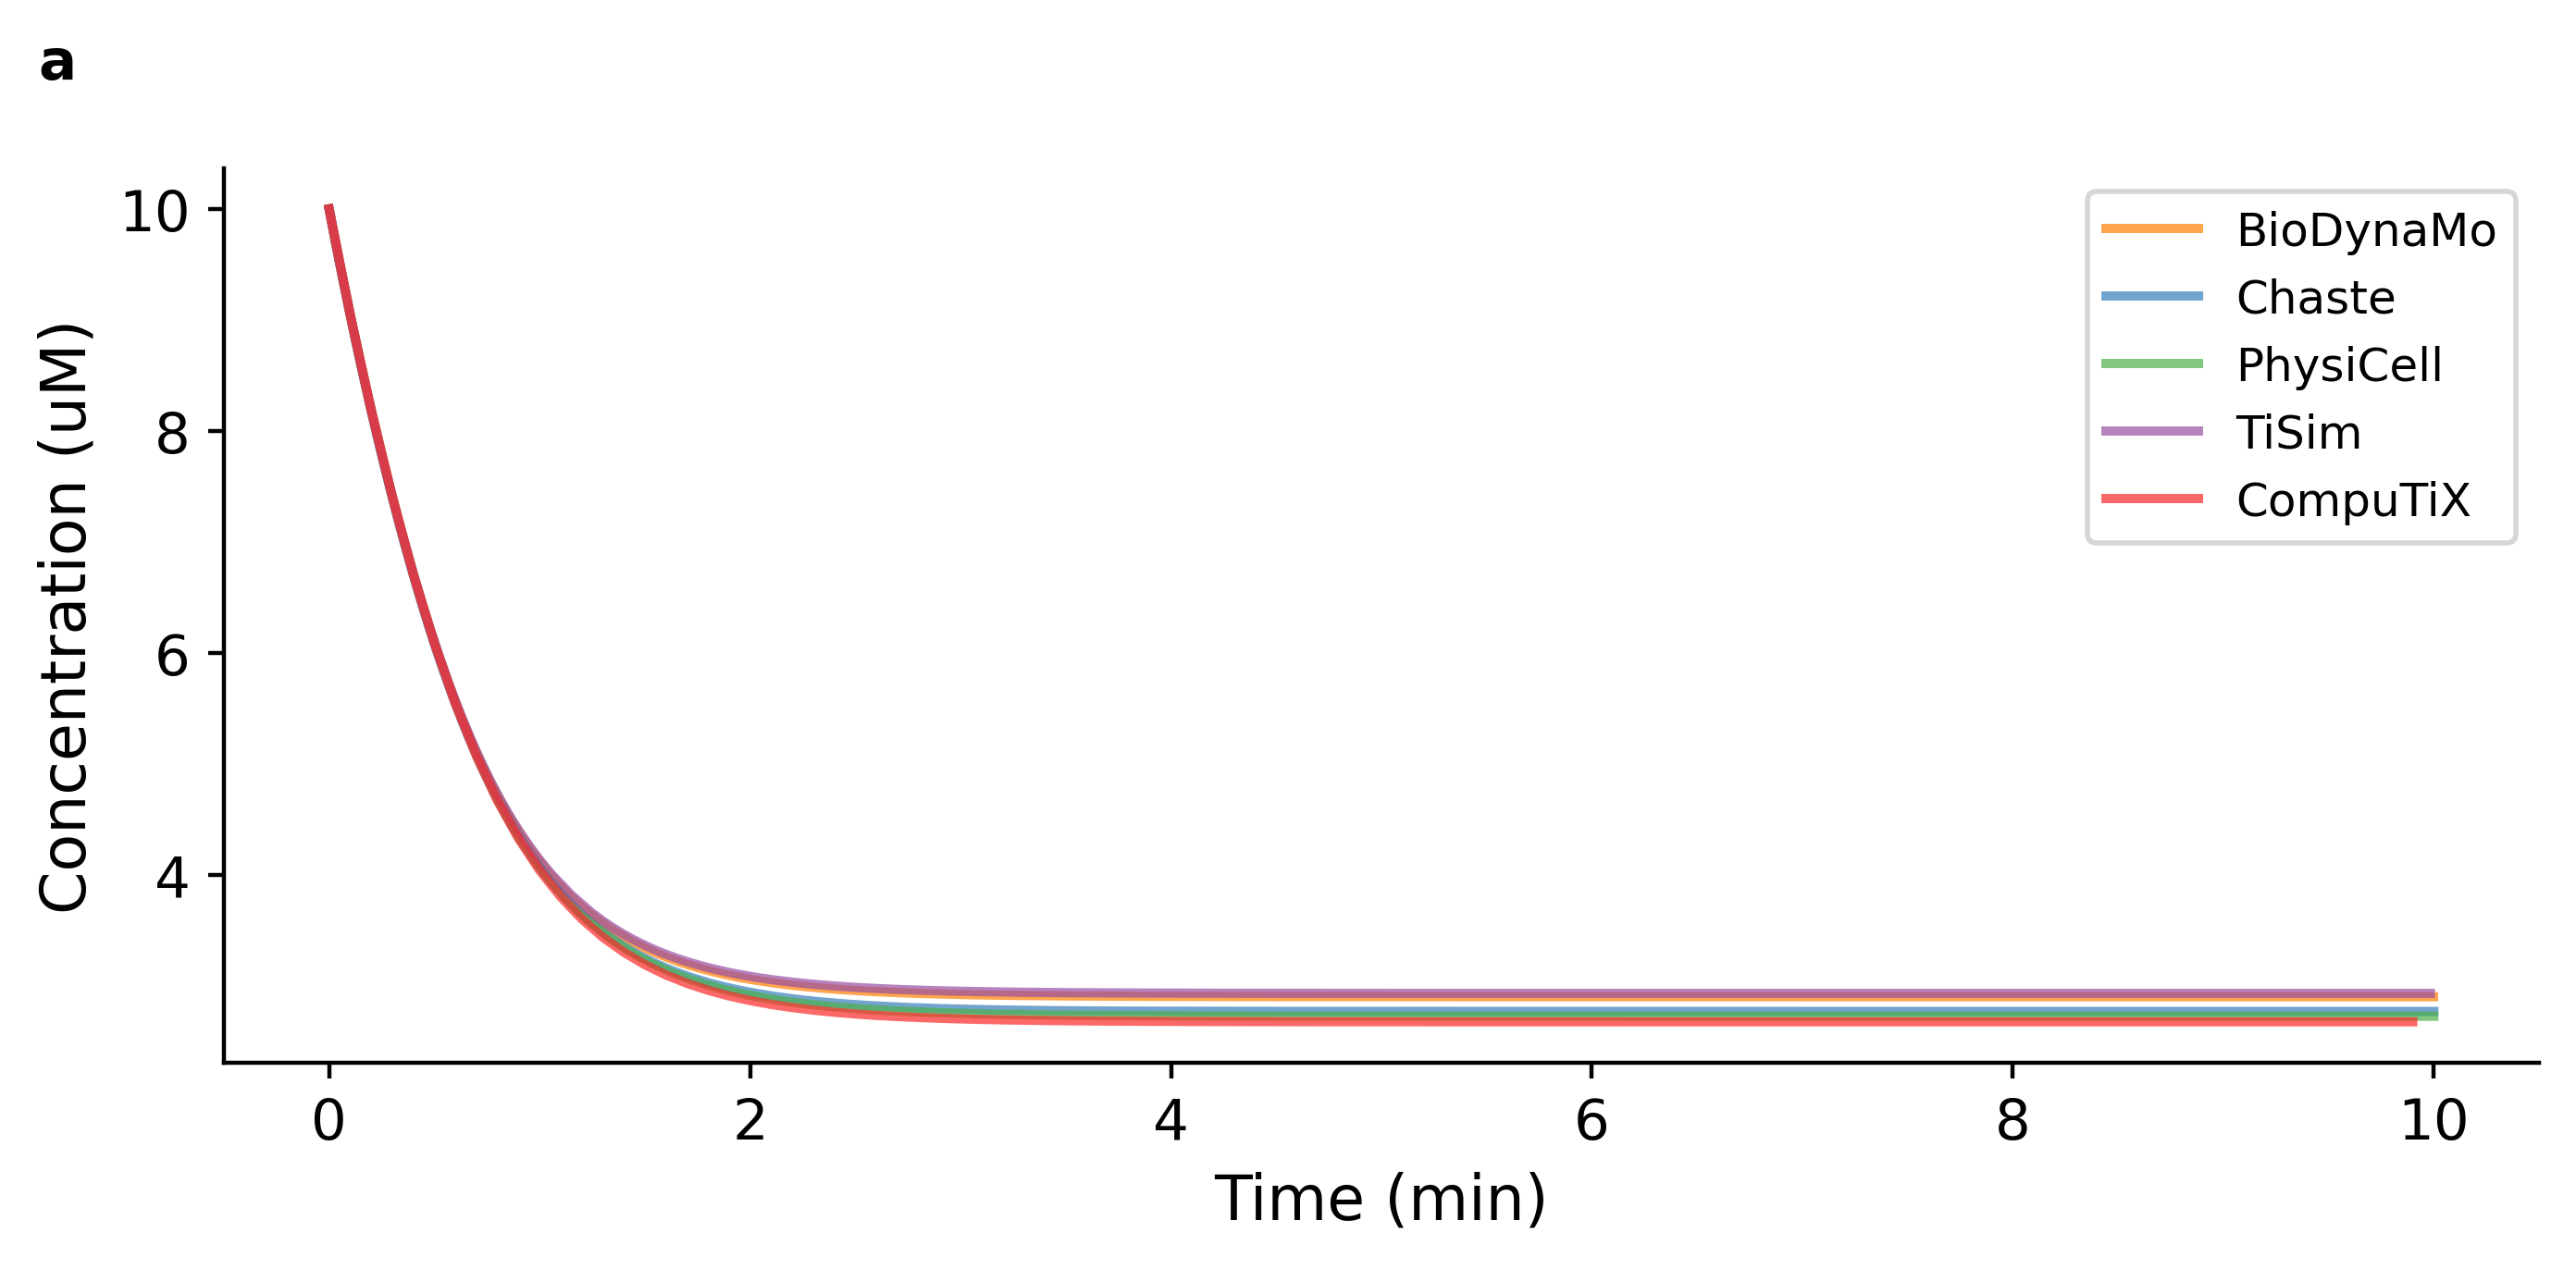

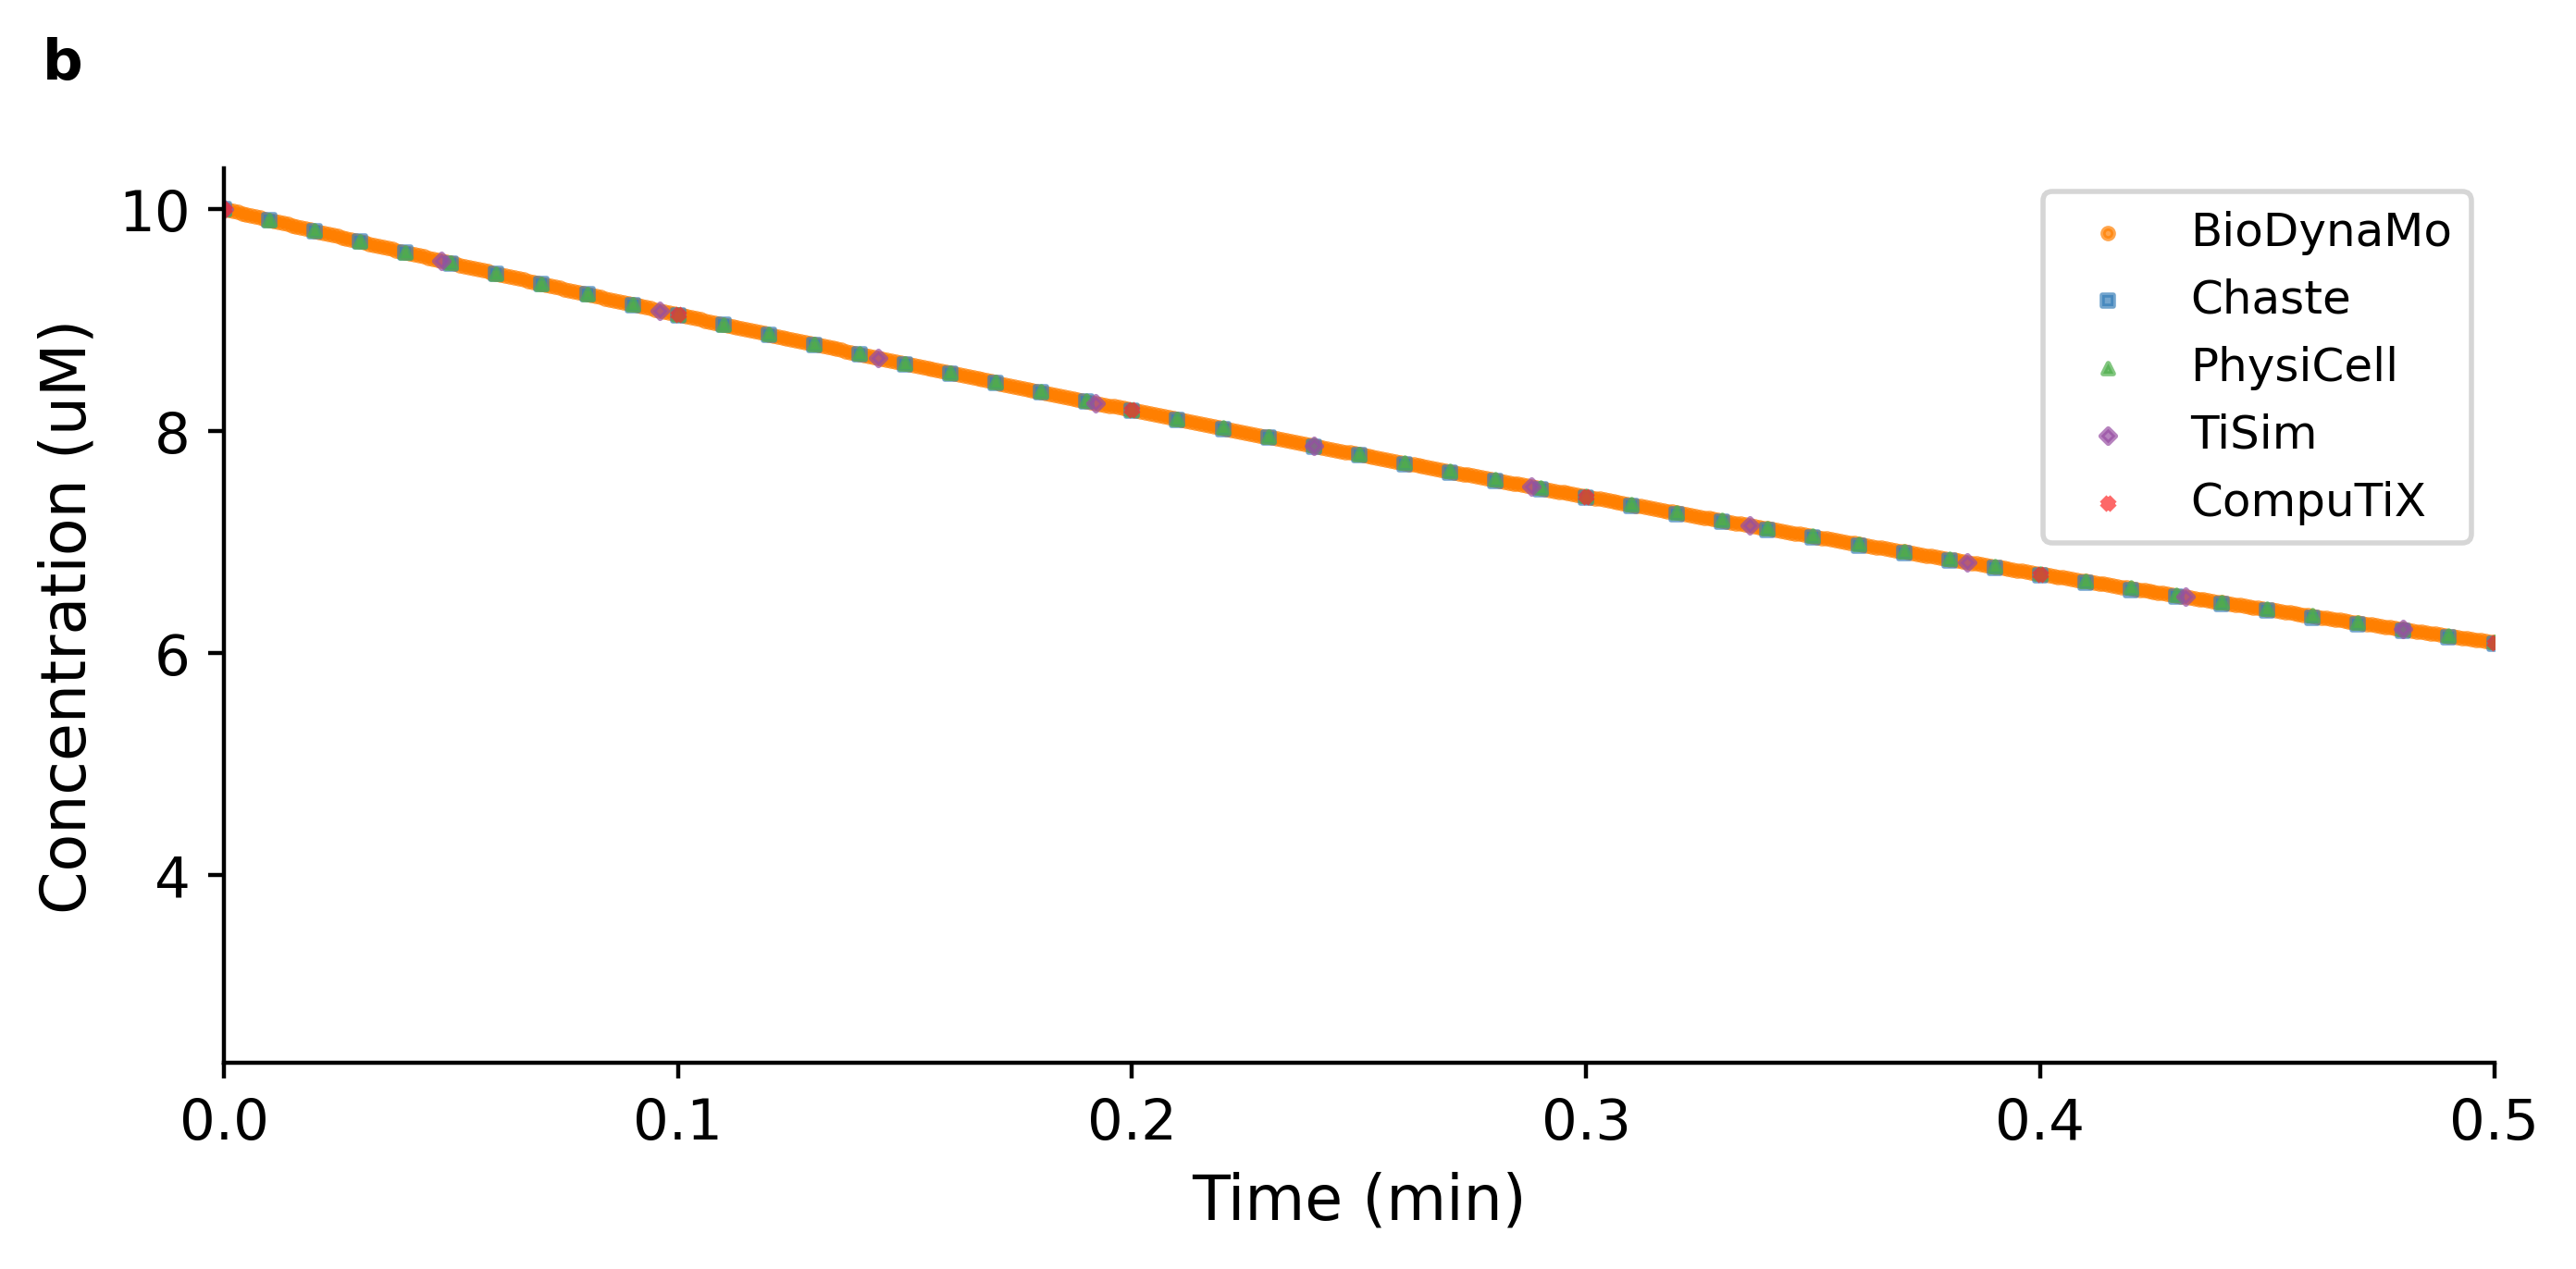

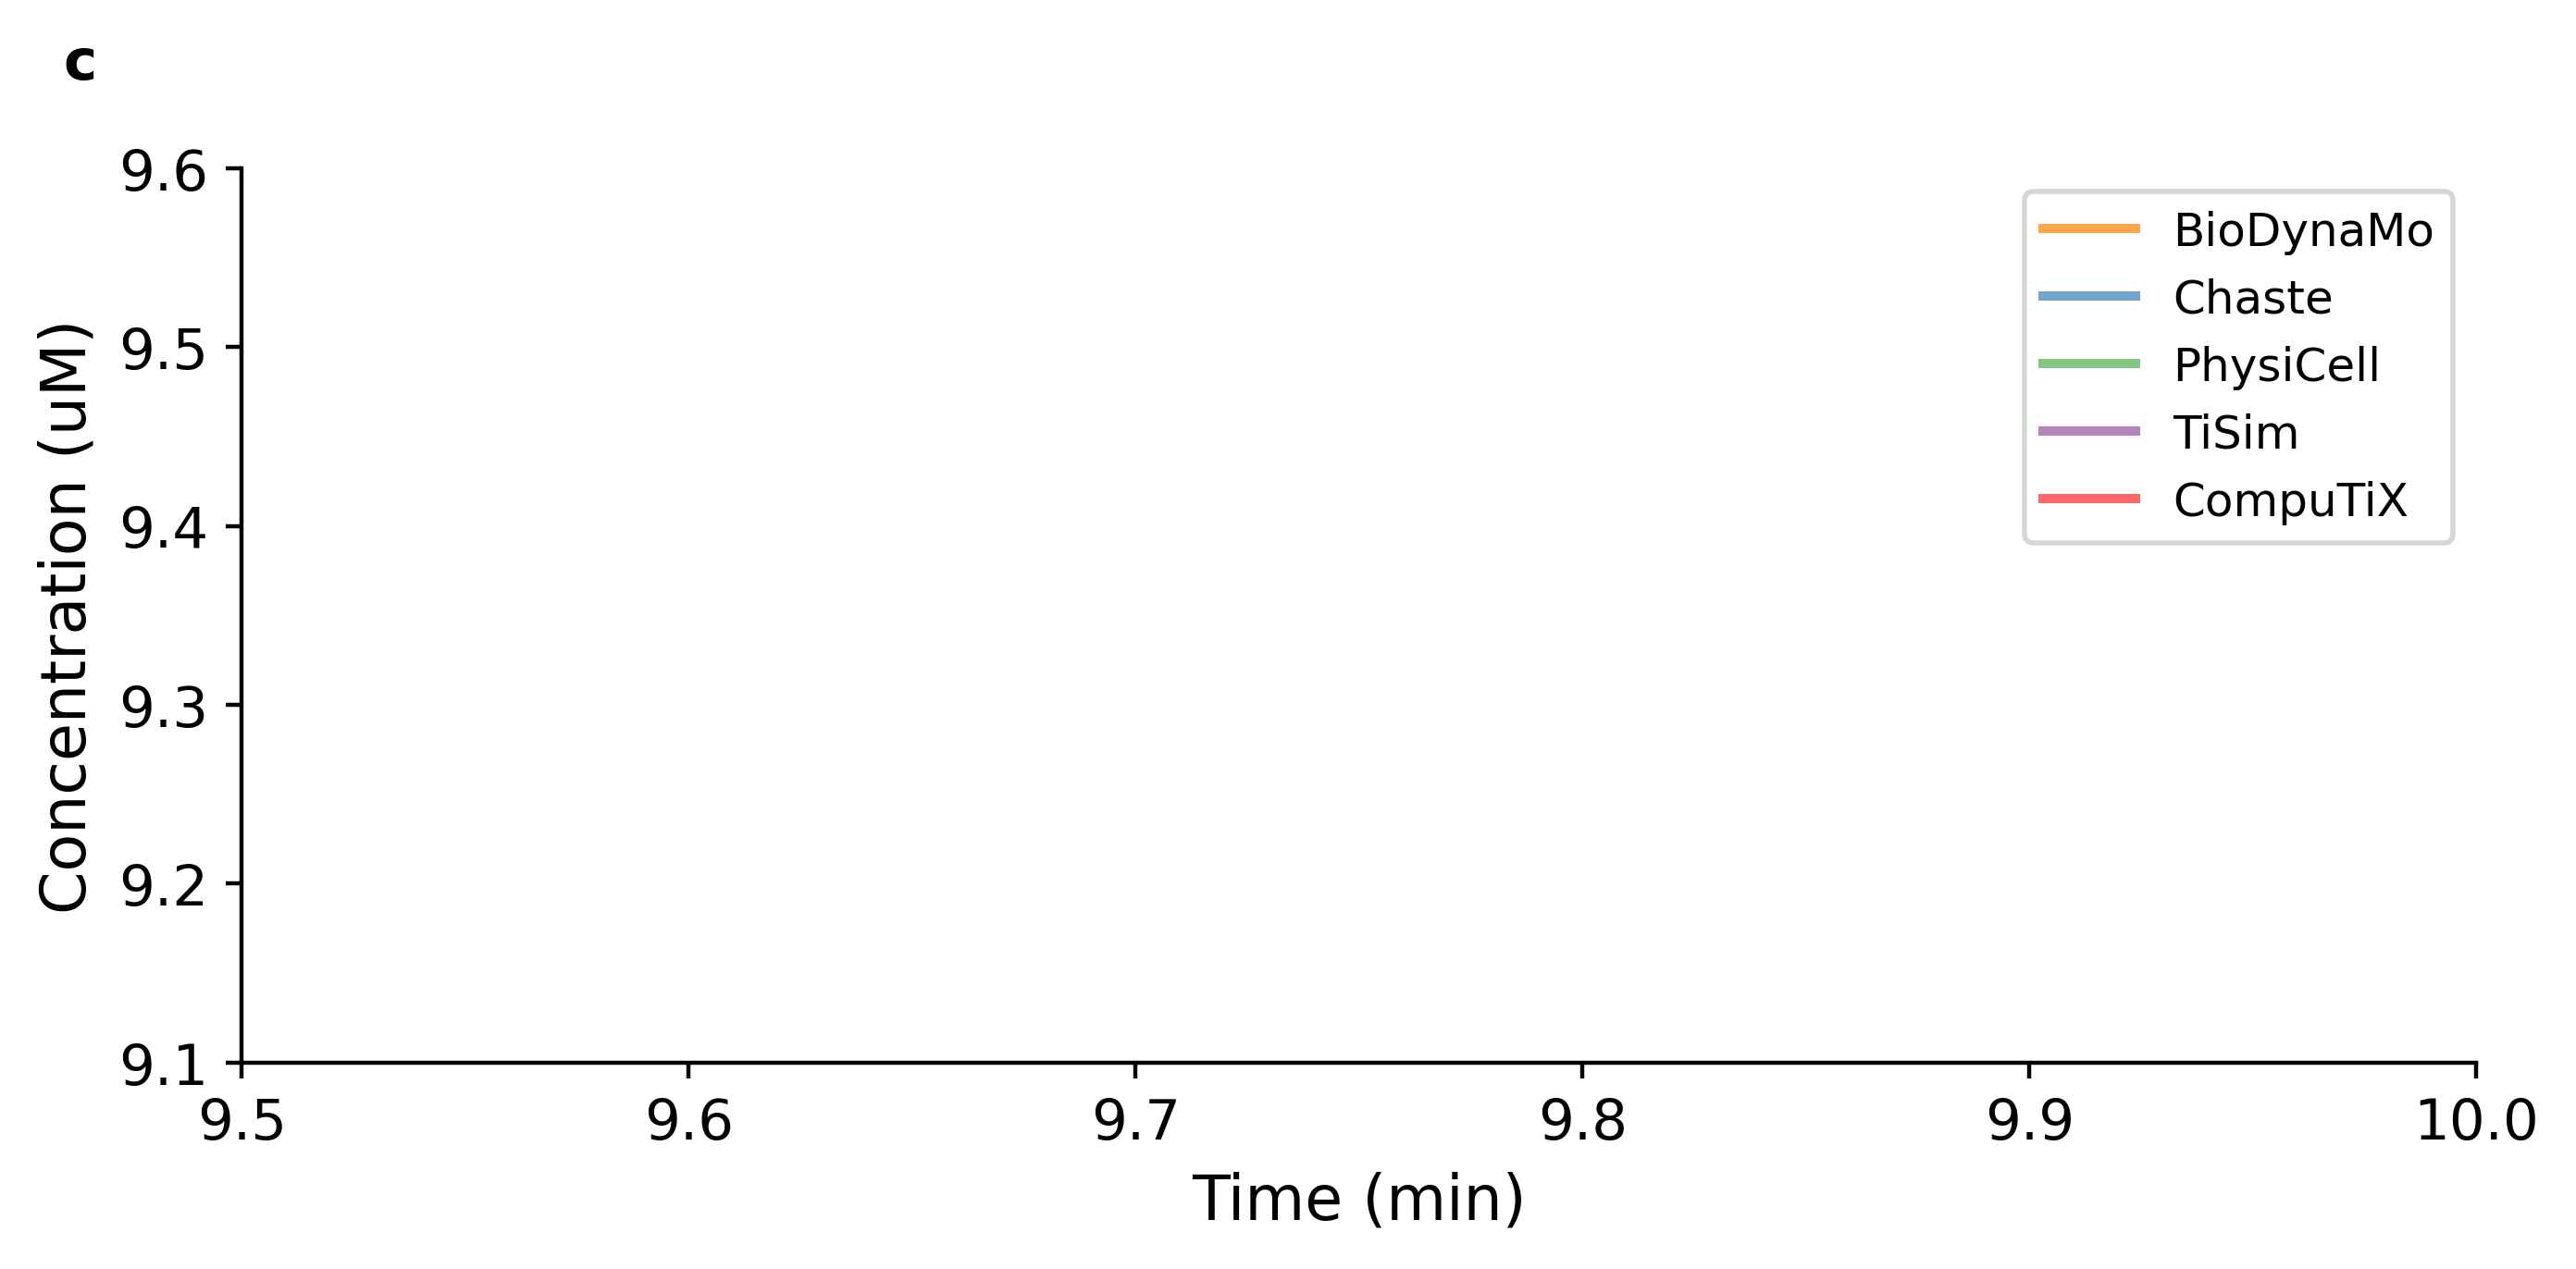

/tmp/ipykernel_20839/2141068204.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.06, 0.06, 1, 0.97])


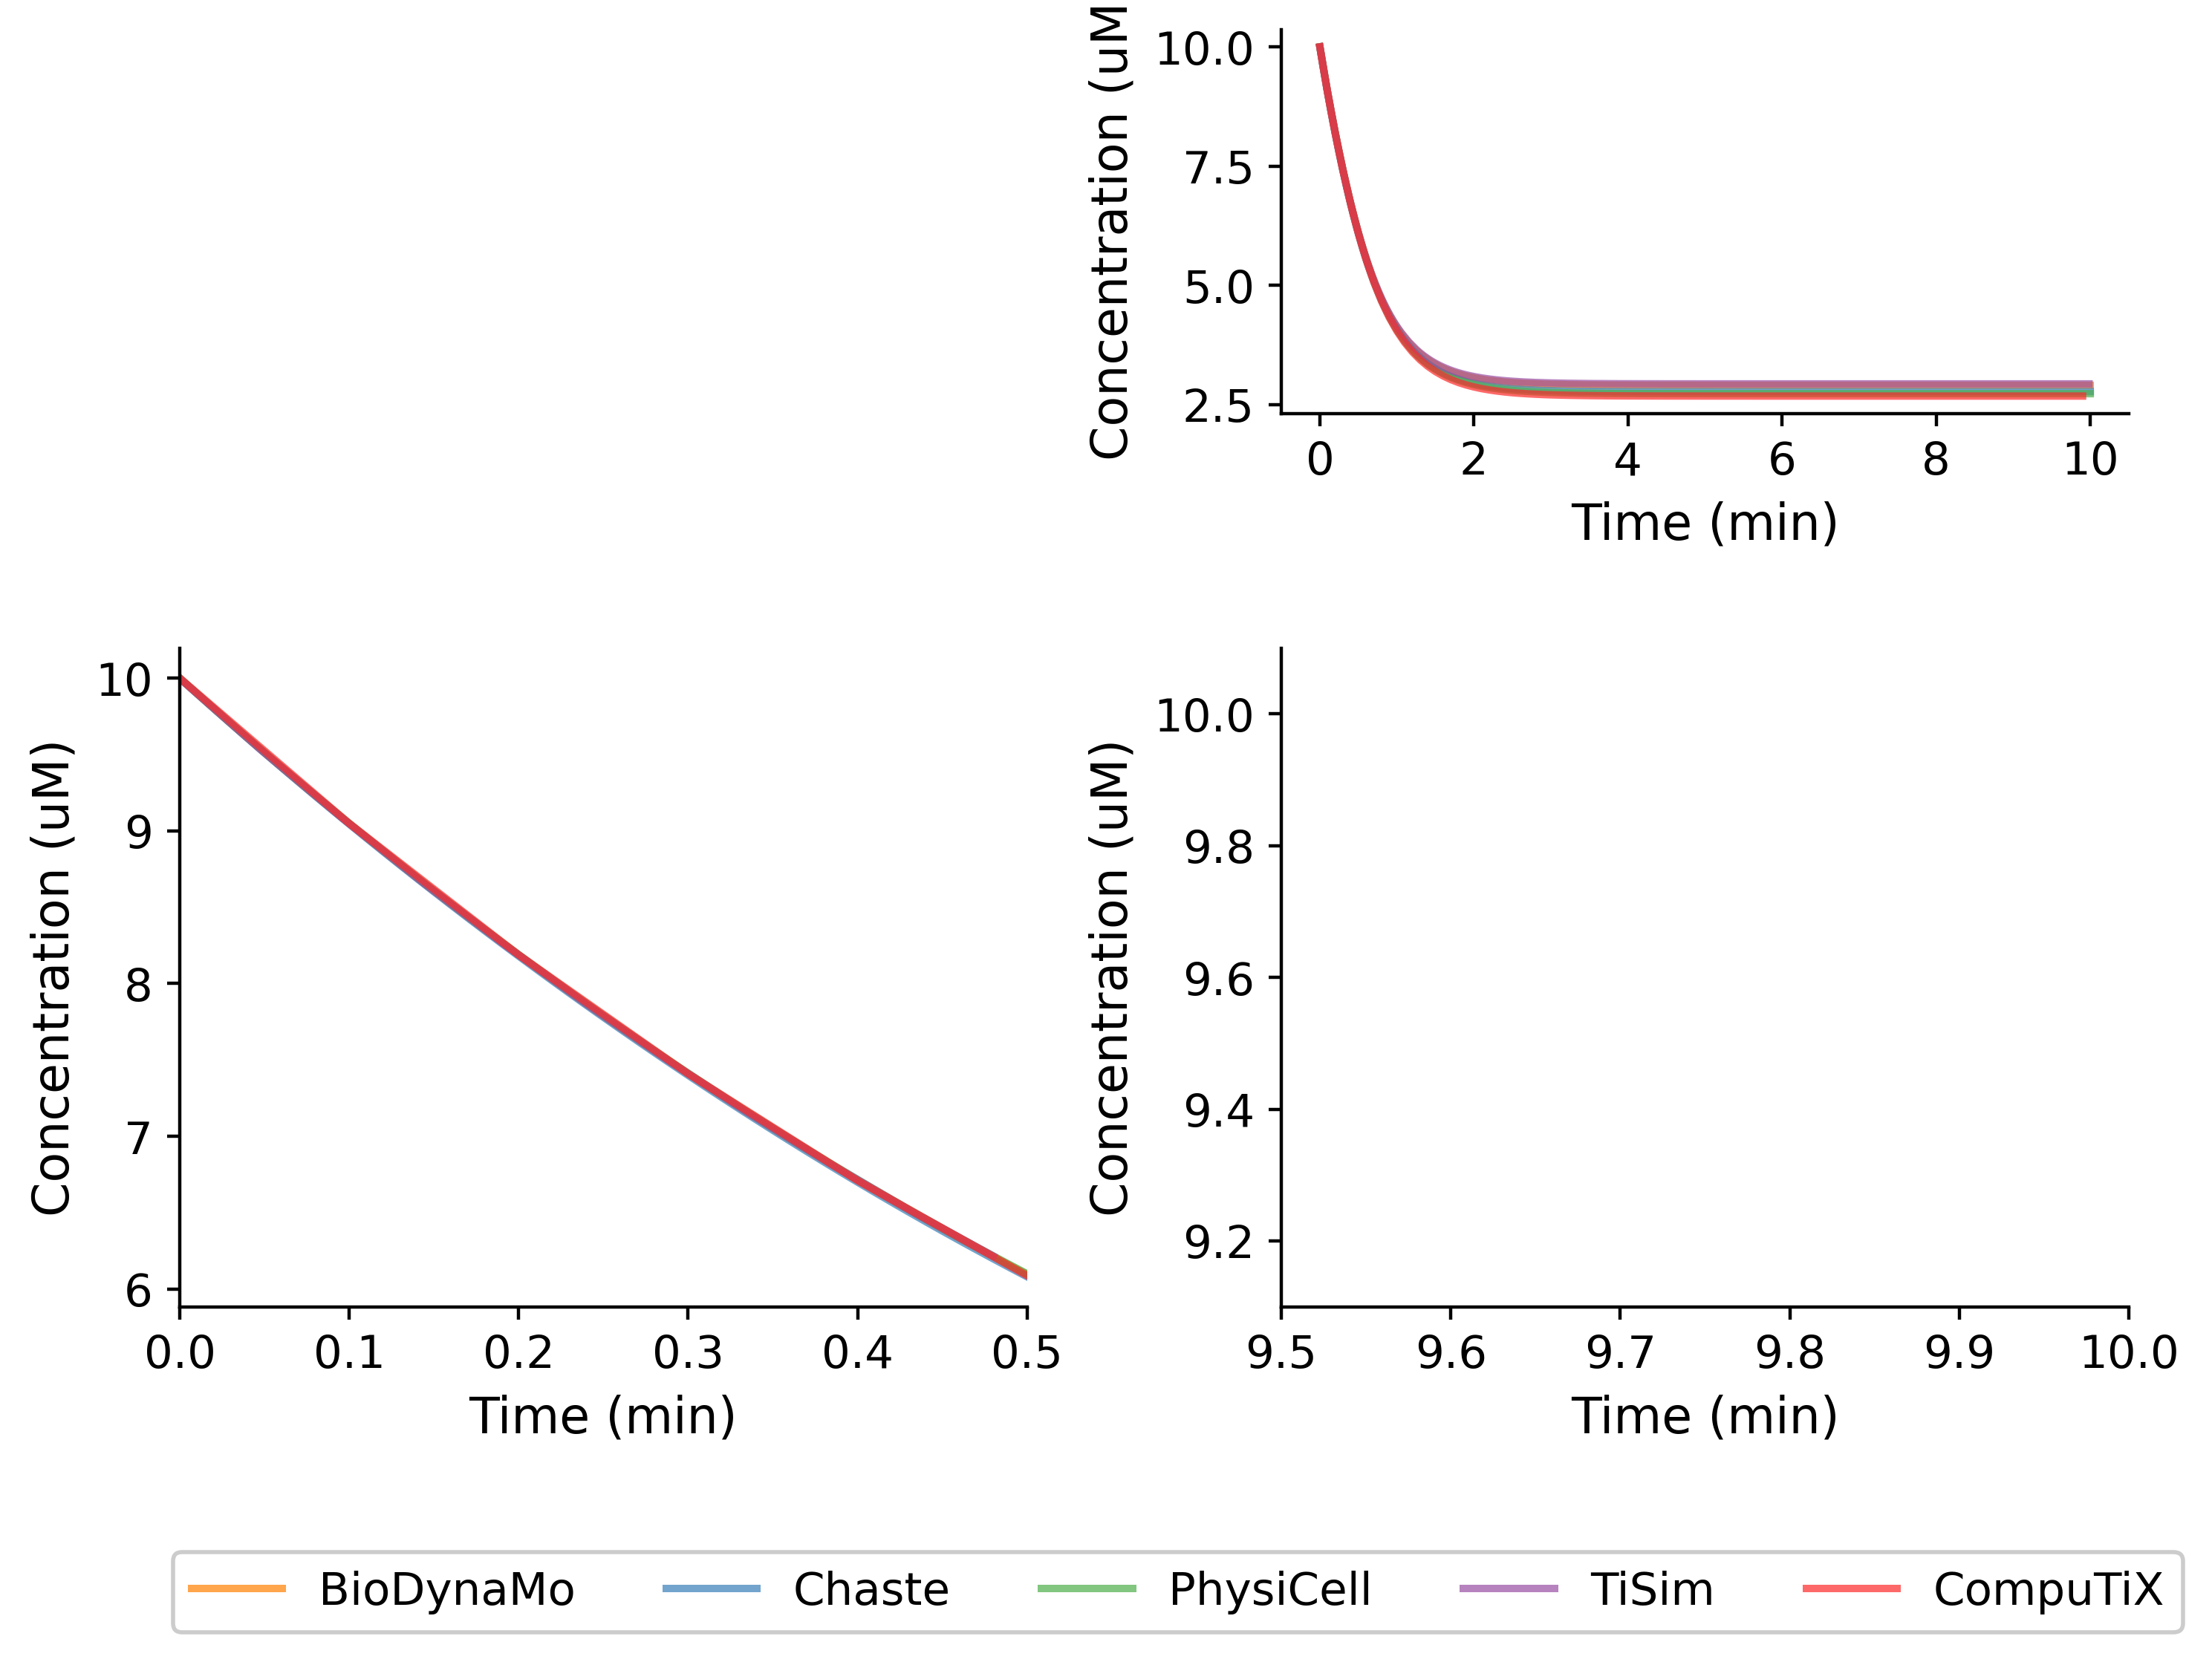

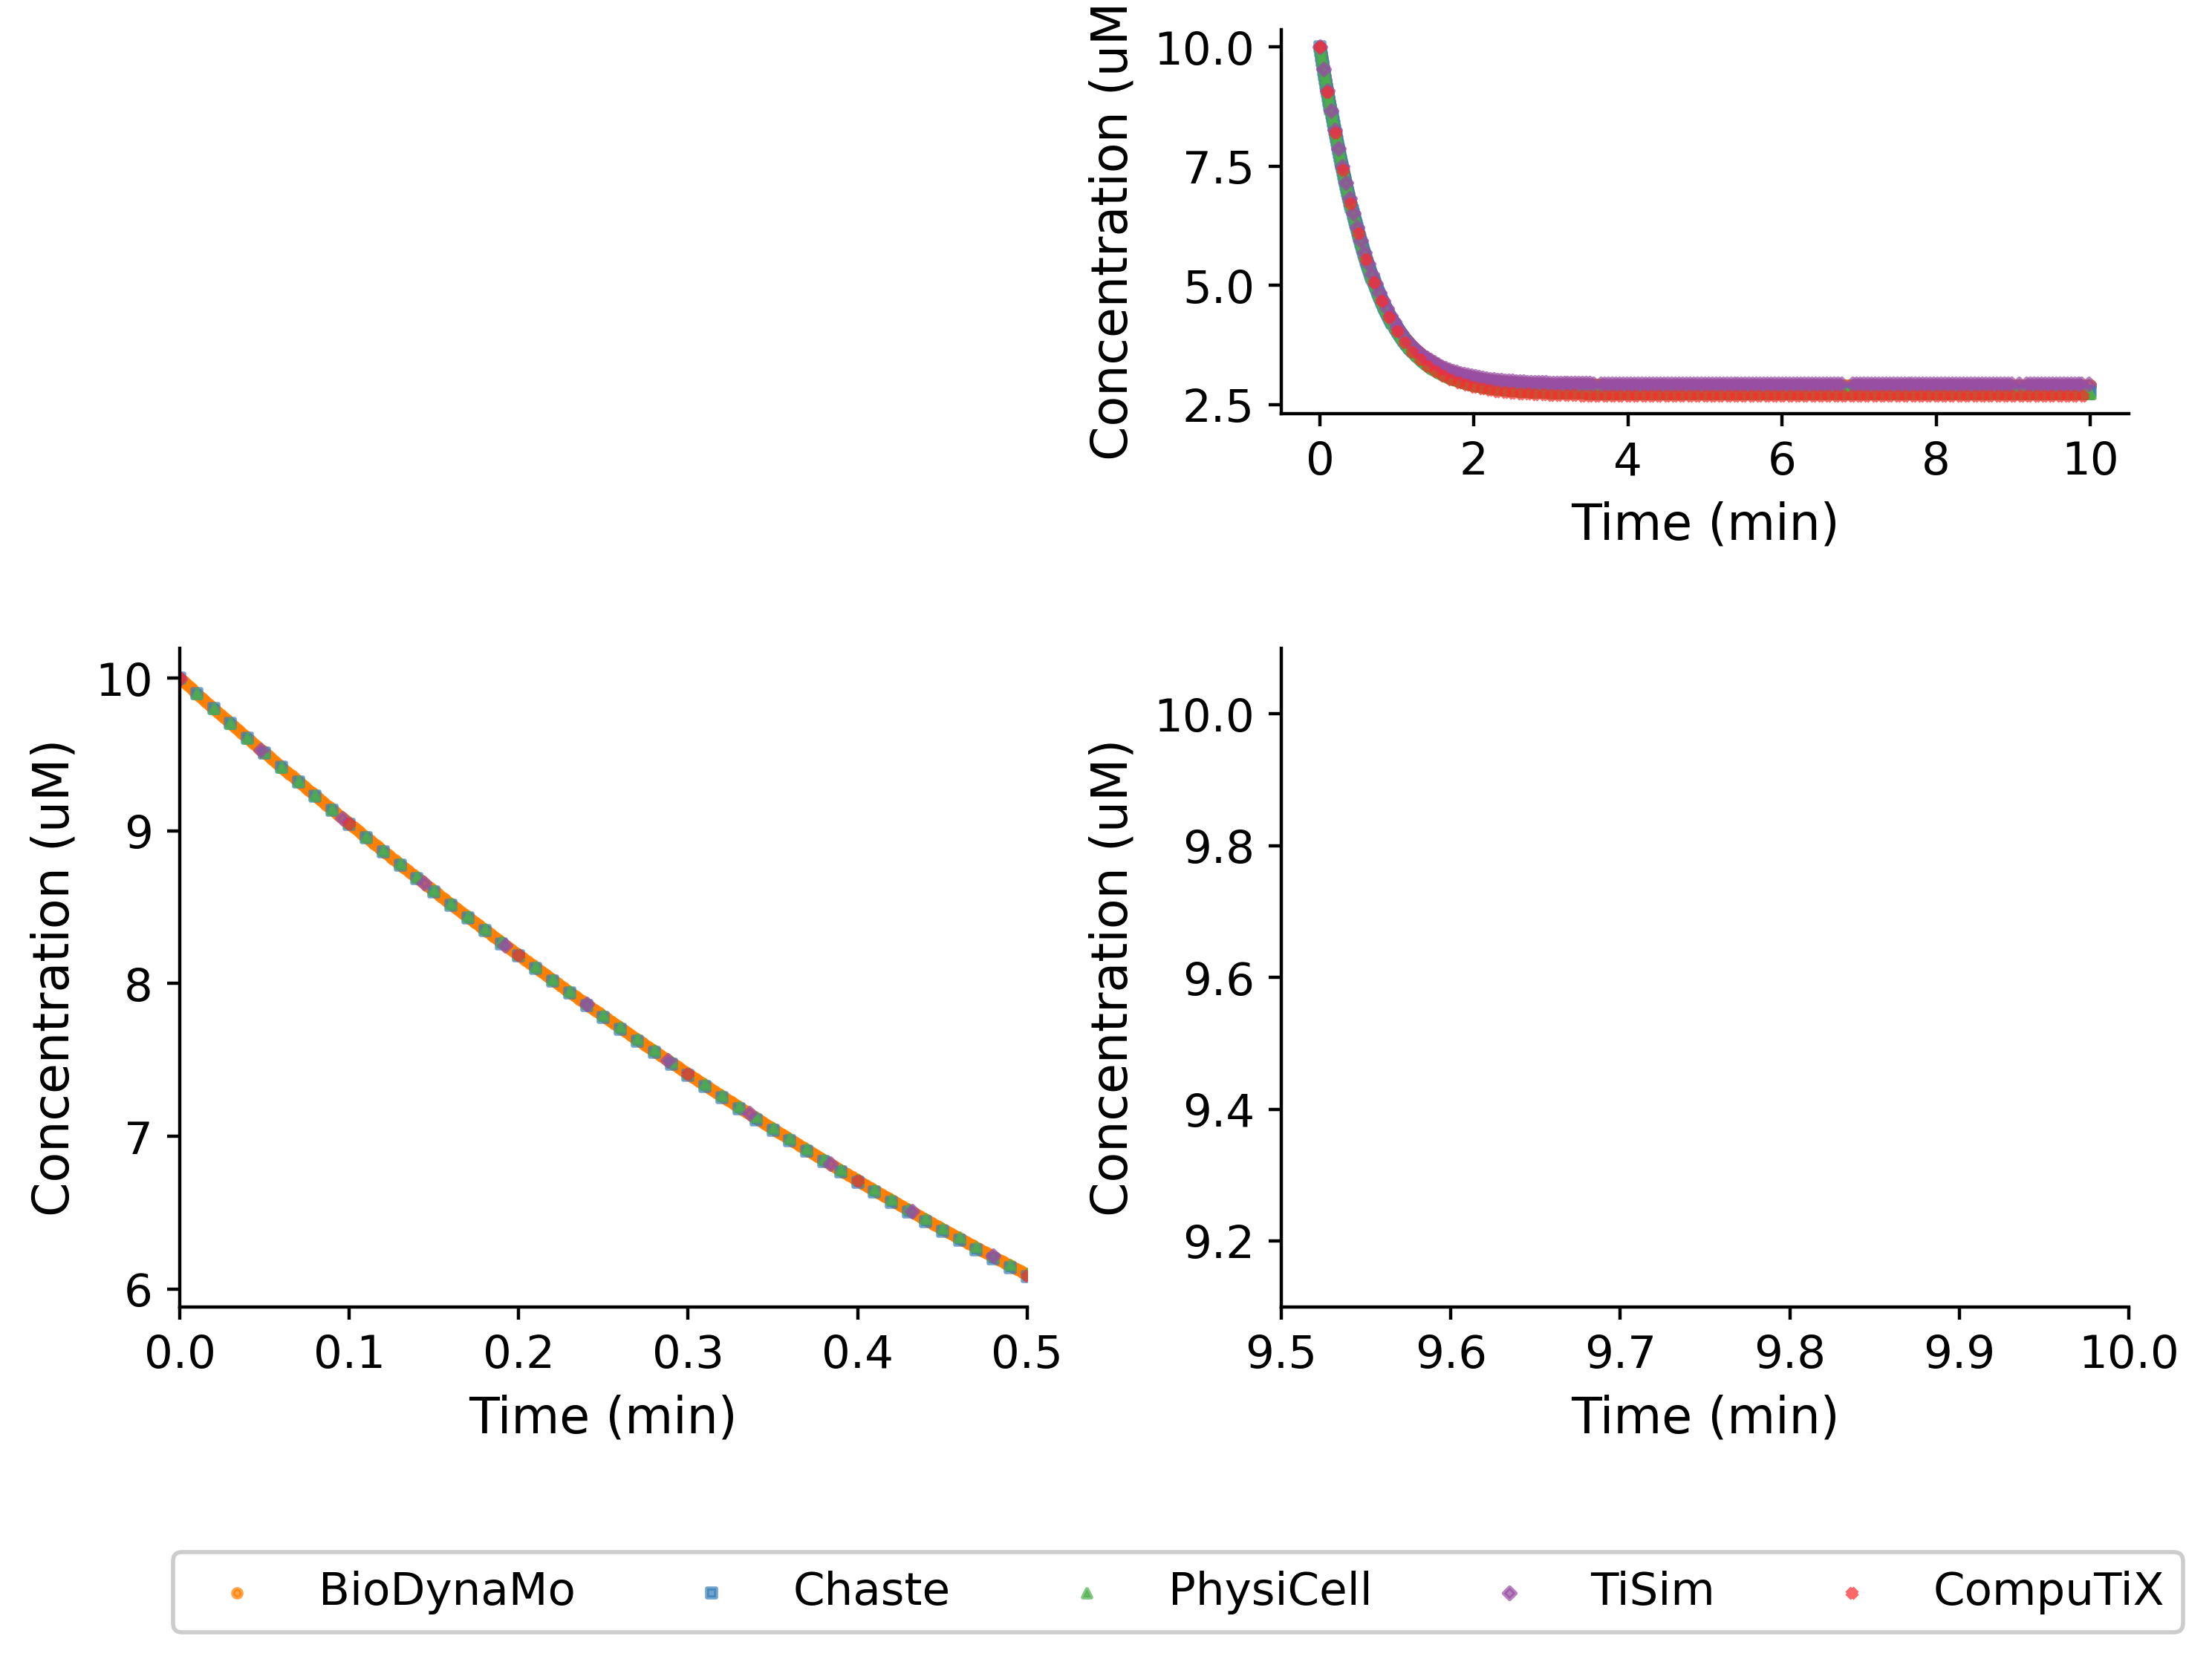

Saved legacy figures to /home/tntiniak/Work/observatory_benchmark/SuppMat/SuppMatPlots/diffusion_single_ut_plots


In [36]:
legacy_plot_dir = ROOT / 'SuppMat' / 'SuppMatPlots' / 'diffusion_single_ut_plots'
legacy_plot_dir.mkdir(parents=True, exist_ok=True)

legacy_colors = {
    'BioDynaMo': '#ff7f00',
    'Chaste': '#377eb8',
    'PhysiCell': '#4daf4a',
    'TiSim': '#984ea3',
    'CompuTiX': '#fd2a2a',
}
legacy_markers = {
    'BioDynaMo': 'o',
    'Chaste': 's',
    'PhysiCell': '^',
    'TiSim': 'D',
    'CompuTiX': 'x',
}
legacy_tools = [tool for tool in ['BioDynaMo', 'Chaste', 'PhysiCell', 'TiSim', 'CompuTiX'] if tool in set(best_average_errors['tool'])]
legacy_center_series = {
    tool: group.sort_values('time_min').reset_index(drop=True)
    for tool, group in best_average_errors.groupby('tool')
}


def _legacy_plot_series(axis, scatter=False, time_limit=None):
    for tool in legacy_tools:
        frame = legacy_center_series[tool]
        if time_limit is not None:
            frame = frame.loc[frame['time_min'] <= time_limit]
        if scatter:
            axis.scatter(
                frame['time_min'], frame['center_uM'], label=tool,
                color=legacy_colors[tool], marker=legacy_markers[tool],
                alpha=0.7, s=4,
            )
        else:
            axis.plot(
                frame['time_min'], frame['center_uM'], label=tool,
                color=legacy_colors[tool], linewidth=1.8, alpha=0.7,
            )


def _style_legacy_axis(axis, xlim=None, ylim=None):
    if xlim is not None:
        axis.set_xlim(*xlim)
    if ylim is not None:
        axis.set_ylim(*ylim)
    axis.set_xlabel('Time (min)', fontsize=12, labelpad=4)
    axis.set_ylabel('Concentration (uM)', fontsize=12, labelpad=4)
    axis.tick_params(axis='both', which='major', labelsize=11)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


def _save_legacy_figure(fig, filename, formats=('png',)):
    for file_format in formats:
        save_kwargs = {'bbox_inches': 'tight', 'pad_inches': 0.2}
        if file_format == 'png':
            save_kwargs['dpi'] = 600
        fig.savefig(legacy_plot_dir / f'{filename}.{file_format}', format=file_format, **save_kwargs)
    plt.show()
    plt.close(fig)


# Standalone full-time, early-time, and late-time center-concentration plots.
for filename, title, xlim, ylim, markers in [
    ('diffusion_full_time', 'a', None, None, False),
    ('diffusion_early_time', 'b', (0, 0.5), None, True),
    ('diffusion_late_time', 'c', (9.5, 10), (9.1, 9.6), False),
]:
    fig, axis = plt.subplots(figsize=(7, 3.5), dpi=400)
    _legacy_plot_series(axis, scatter=markers, time_limit=10)
    _style_legacy_axis(axis, xlim=xlim, ylim=ylim)
    axis.text(-0.08, 1.1, title, transform=axis.transAxes, fontsize=11, fontweight='bold')
    axis.legend(frameon=True, fontsize=9)
    fig.tight_layout()
    _save_legacy_figure(fig, filename)


def _create_legacy_composite(scatter=False):
    fig = plt.figure(figsize=(8, 5))
    grid = gridspec.GridSpec(
        2, 2, height_ratios=[0.7, 1.2], width_ratios=[1, 1],
        hspace=0.45, wspace=0.3,
    )
    empty_axis = fig.add_subplot(grid[0, 0])
    empty_axis.axis('off')

    full_axis = fig.add_subplot(grid[0, 1])
    _legacy_plot_series(full_axis, scatter=scatter, time_limit=10)
    _style_legacy_axis(full_axis)

    early_axis = fig.add_subplot(grid[1, 0])
    _legacy_plot_series(early_axis, scatter=scatter, time_limit=0.5)
    _style_legacy_axis(early_axis, xlim=(0, 0.5))

    late_axis = fig.add_subplot(grid[1, 1])
    _legacy_plot_series(late_axis, scatter=scatter, time_limit=10)
    _style_legacy_axis(late_axis, xlim=(9.5, 10), ylim=(9.1, 10.1))

    handles, labels = full_axis.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.04),
               ncol=5, frameon=True, framealpha=1.0, fontsize=11)
    fig.tight_layout(rect=[0.06, 0.06, 1, 0.97])
    fig.subplots_adjust(left=0.08, top=0.97, hspace=0.45, wspace=0.3)
    return fig


line_figure = _create_legacy_composite(scatter=False)
_save_legacy_figure(line_figure, 'diffusion_single_ut', formats=('svg', 'png'))

scatter_figure = _create_legacy_composite(scatter=True)
_save_legacy_figure(scatter_figure, 'diffusion_single_ut_scatter', formats=('pdf', 'svg', 'png'))

print(f'Saved legacy figures to {legacy_plot_dir}')